In [ ]:
# ==========================================================
# Install Required Packages (Run Only Once)
# ==========================================================

!pip -q install torchdiffeq

In [ ]:
# --------------------------------------------------
# BLOCK 1 : Imports
# --------------------------------------------------

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchdiffeq import odeint

warnings.filterwarnings("ignore")

# --------------------------------------------------
# Device Configuration
# --------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device :", device)

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device : cpu


In [ ]:
# --------------------------------------------------
# BLOCK 2 : Influenza Model Parameters
# --------------------------------------------------

params = {
    "Lambda": 0.06,
    "mu": 1/(80*365),
    "alpha": 0.20,
    "nu": 0.00057,
    "delta": 0.001,
    "beta0": 1.5378,
    "amp": 0.40,
    "omega": 0.0038,
    "C": 0.010,
    "d": 13.9394
}

print("Mechanistic Parameters")
for key, value in params.items():
    print(f"{key:10s} : {value}")

Mechanistic Parameters
Lambda     : 0.06
mu         : 3.424657534246575e-05
alpha      : 0.2
nu         : 0.00057
delta      : 0.001
beta0      : 1.5378
amp        : 0.4
omega      : 0.0038
C          : 0.01
d          : 13.9394


In [ ]:
# --------------------------------------------------
# BLOCK 3 : Seasonal Residual Neural Network
# --------------------------------------------------

class SeasonalResidualNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(8, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # Xavier Initialization
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, X, t):
        # Annual seasonal cycle
        sin1 = torch.sin(2*math.pi*t/52)
        cos1 = torch.cos(2*math.pi*t/52)

        # Semi-annual seasonal cycle
        sin2 = torch.sin(4*math.pi*t/52)
        cos2 = torch.cos(4*math.pi*t/52)

        features = torch.cat([X, t, sin1, cos1, sin2, cos2], dim=1)

        residual = self.network(features)

        # Limit residual magnitude
        residual = 0.8*torch.tanh(residual)

        return residual

In [ ]:
# --------------------------------------------------
# BLOCK 4 : UDE ODE Function
# --------------------------------------------------

def influenza_rhs_ude(t, X, model, params):
    S = X[:, 0:1]
    I = X[:, 1:2]
    R = X[:, 2:3]

    Lambda = params["Lambda"]
    mu     = params["mu"]
    alpha  = params["alpha"]
    nu     = params["nu"]
    delta  = params["delta"]
    omega  = params["omega"]
    C      = params["C"]
    d      = params["d"]

    beta = params["beta0"] * (1 + params["amp"] * torch.cos(2 * math.pi * t / 52))

    t_input = torch.ones_like(S) * t
    residual = model(X, t_input)
    beta = beta + residual
    beta = torch.clamp(beta, min=0.02, max=5.0)

    N = S + I + R + 1e-8

    dS = Lambda - beta*S*I/N - (mu+nu)*S + omega*R
    dI = beta*S*I/N - (mu+alpha+delta)*I - (C*I)/(1+d*I)
    dR = alpha*I - (mu+omega)*R + nu*S + (C*I)/(1+d*I)

    return torch.cat([dS, dI, dR], dim=1)


# --------------------------------------------------
# ODE Wrapper
# --------------------------------------------------

class ODEFunc(nn.Module):
    def __init__(self, model, params):
        super().__init__()
        self.model = model
        self.params = params

    def forward(self, t, X):
        return influenza_rhs_ude(t, X, self.model, self.params)

In [ ]:
# --------------------------------------------------
# BLOCK 5 : Optimizer + Scheduler
# --------------------------------------------------

seasonal_residual_nn = SeasonalResidualNN().to(device)

ode_func = ODEFunc(seasonal_residual_nn, params).to(device)

loss_fn = nn.MSELoss()

optimizer = optim.AdamW(
    seasonal_residual_nn.parameters(),
    lr=2e-4,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=100
)

print("Optimizer and Scheduler initialized.")

Optimizer and Scheduler initialized.


In [ ]:
# --------------------------------------------------
# BLOCK 6 : Data Preparation
# --------------------------------------------------

data = pd.read_csv("/content/California.csv")
print(data.head())
print(data.columns)

t_data = np.arange(len(data), dtype=np.float32)

I_obs = data["Total_ILI"].values.astype(np.float32)
I_obs = I_obs / np.max(I_obs)

I_obs_tensor = torch.tensor(I_obs, dtype=torch.float32, device=device)

# --------------------------------------------------
# Initial Conditions — anchored to the true first data point
# --------------------------------------------------

I0 = I_obs_tensor[0].item()
R0 = 0.0
S0 = 1.0 - I0 - R0

if S0 < 0:
    print("Warning: Calculated S0 is negative, adjusting to ensure S0 >= 0.")
    S0 = 0.0
    R0 = 1.0 - I0

X0 = torch.tensor([[S0, I0, R0]], dtype=torch.float32, device=device)

t_tensor = torch.tensor(t_data, dtype=torch.float32, device=device)

print("Number of observations:", len(t_data))
print("Initial condition:", X0)

      season  date_code  weekending      region  Total_ILI  \
0  2016-2017     201701  01-07-2017  California       2686   
1  2016-2017     201702   1/14/2017  California       2398   
2  2016-2017     201703   1/21/2017  California       2277   
3  2016-2017     201704   1/28/2017  California       2503   
4  2016-2017     201705  02-04-2017  California       2450   

   Total_Patients_Seen  Percent_ILI  Number_Providers_Reporting  
0                70547         3.81                         162  
1                71259         3.37                         156  
2                72819         3.13                         156  
3                75796         3.30                         156  
4                74251         3.30                         148  
Index(['season', 'date_code', 'weekending', 'region', 'Total_ILI',
       'Total_Patients_Seen', 'Percent_ILI', 'Number_Providers_Reporting'],
      dtype='object')
Number of observations: 195
Initial condition: tensor([[0.5362, 0.

In [ ]:
# --------------------------------------------------
# BLOCK 6.5 : Mechanistic Parameter Calibration (FIXED)
# --------------------------------------------------

print("Starting Mechanistic Calibration ...")

# --------------------------------------------------
# Learnable Parameters  (ONLY beta0 and I0 — C, d stay FIXED, same as original)
# --------------------------------------------------

beta0 = nn.Parameter(
    torch.tensor(params["beta0"], dtype=torch.float32, device=device)
)

# Bound I0 around the TRUE observed first value instead of a hard 0.05 cap
I0_true = I_obs[0]
I0_lo, I0_hi = max(0.001, I0_true * 0.5), min(0.99, I0_true * 1.5)

def inv_sigmoid_scaled(val, lo, hi):
    frac = (val - lo) / (hi - lo)
    frac = min(max(frac, 1e-4), 1 - 1e-4)
    return math.log(frac / (1 - frac))

I0_param = nn.Parameter(
    torch.tensor([[inv_sigmoid_scaled(I0_true, I0_lo, I0_hi)]], dtype=torch.float32, device=device)
)

# --------------------------------------------------
# Mechanistic ODE  (C and d fixed, exactly like the original working version)
# --------------------------------------------------

class MechanisticODECalibration(nn.Module):
    def __init__(self, params):
        super().__init__()
        self.params = params

    def forward(self, t, X):
        S, I, R = X[:,0:1], X[:,1:2], X[:,2:3]
        beta = F.softplus(beta0)
        beta = beta * (1 + self.params["amp"] * torch.cos(2*math.pi*t/52))
        beta = torch.clamp(beta, 0.02, 5.0)

        N = S + I + R + 1e-8
        dS = self.params["Lambda"] - beta*S*I/N - (self.params["mu"]+self.params["nu"])*S + self.params["omega"]*R
        dI = beta*S*I/N - (self.params["mu"]+self.params["alpha"]+self.params["delta"])*I - (self.params["C"]*I)/(1+self.params["d"]*I)
        dR = self.params["alpha"]*I - (self.params["mu"]+self.params["omega"])*R + self.params["nu"]*S + (self.params["C"]*I)/(1+self.params["d"]*I)
        return torch.cat([dS,dI,dR], dim=1)

calibration_model = MechanisticODECalibration(params).to(device)

# --------------------------------------------------
# Optimizer  (only beta0, I0_param — same as original)
# --------------------------------------------------

optimizer_calib = optim.AdamW([beta0, I0_param], lr=3e-3, weight_decay=1e-6)
scheduler_calib = optim.lr_scheduler.ReduceLROnPlateau(optimizer_calib, mode="min", factor=0.5, patience=30)

best_loss = float("inf")
best_beta = None
best_I0 = None

# --------------------------------------------------
# Training
# --------------------------------------------------

for epoch in range(250):
    optimizer_calib.zero_grad()

    I0 = torch.sigmoid(I0_param) * (I0_hi - I0_lo) + I0_lo   # <-- fixed: bounded near true I0, not capped at 0.05
    R0 = torch.zeros_like(I0)
    S0 = 1.0 - I0 - R0                                        # <-- fixed: derived from I0, not hardcoded 0.99
    X0_fit = torch.cat([S0, I0, R0], dim=1)

    pred = odeint(calibration_model, X0_fit, t_tensor, method="rk4")
    if pred.dim() == 3: pred = pred.squeeze(1)

    loss = F.mse_loss(pred[:,1], I_obs_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_([beta0, I0_param], 1.0)
    optimizer_calib.step()
    scheduler_calib.step(loss.item())

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_beta = F.softplus(beta0).detach().clone()
        best_I0 = I0.detach().clone()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Loss={loss.item():.6f} | beta0={F.softplus(beta0).item():.4f} | I0={I0.item():.4f}")

# --------------------------------------------------
# Update Global Parameters
# --------------------------------------------------

params["beta0"] = best_beta.item()
I0_val = best_I0.item()
S0_val = 1.0 - I0_val
X0 = torch.tensor([[S0_val, I0_val, 0.0]], dtype=torch.float32, device=device)

print("\nCalibration Finished")
print(f"Best Loss : {best_loss:.6f}")
print(f"Estimated beta0 : {params['beta0']:.4f}")
print(f"Estimated I0 : {I0_val:.5f}  (true observed I0 = {I_obs[0]:.5f})")
print(f"Final X0 : {X0}")

Starting Mechanistic Calibration ...
Epoch   0 | Loss=0.046437 | beta0=1.7300 | I0=0.4638
Epoch  50 | Loss=0.045865 | beta0=1.6037 | I0=0.4800
Epoch 100 | Loss=0.044926 | beta0=1.4627 | I0=0.4900
Epoch 150 | Loss=0.043361 | beta0=1.3076 | I0=0.4898
Epoch 200 | Loss=0.041194 | beta0=1.1524 | I0=0.4787

Calibration Finished
Best Loss : 0.038089
Estimated beta0 : 1.0004
Estimated I0 : 0.46073  (true observed I0 = 0.46382)
Final X0 : tensor([[0.5393, 0.4607, 0.0000]])


In [ ]:
# --------------------------------------------------
# BLOCK 7 : UDE Training (Self-Contained)
# --------------------------------------------------

class SeasonalResidualNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(8,128), nn.Tanh(),
            nn.Linear(128,128), nn.Tanh(),
            nn.Linear(128,64), nn.Tanh(),
            nn.Linear(64,1)
        )
    def forward(self,X,t):
        sin1, cos1 = torch.sin(2*math.pi*t/52), torch.cos(2*math.pi*t/52)
        sin2, cos2 = torch.sin(4*math.pi*t/52), torch.cos(4*math.pi*t/52)
        features = torch.cat([X, t, sin1, cos1, sin2, cos2], dim=1)
        return 1.0 * torch.tanh(self.network(features))

class ODEFunc(nn.Module):
    def __init__(self, model, params):
        super().__init__()
        self.model = model
        self.params = params
    def forward(self, t, X):
        S, I, R = X[:,0:1], X[:,1:2], X[:,2:3]
        beta = self.params["beta0"] * (1 + self.params["amp"] * torch.cos(2 * math.pi * t / 52))
        t_input = torch.ones_like(S) * t
        beta = torch.clamp(beta + self.model(X, t_input), 0.02, 5.0)
        N = S + I + R + 1e-8
        dS = self.params["Lambda"] - beta*S*I/N - (self.params["mu"]+self.params["nu"])*S + self.params["omega"]*R
        dI = beta*S*I/N - (self.params["mu"]+self.params["alpha"]+self.params["delta"])*I - (self.params["C"]*I)/(1+self.params["d"]*I)
        dR = self.params["alpha"]*I - (self.params["mu"]+self.params["omega"])*R + self.params["nu"]*S + (self.params["C"]*I)/(1+self.params["d"]*I)
        return torch.cat([dS,dI,dR],dim=1)

seasonal_residual_nn = SeasonalResidualNN().to(device)
ode_func = ODEFunc(seasonal_residual_nn, params).to(device)
optimizer = optim.AdamW(seasonal_residual_nn.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=50)
loss_fn = nn.MSELoss()

print("Starting UDE Training...")
num_epochs, best_loss, patience, counter = 500, float("inf"), 100, 0
loss_history = []                      # <-- must be defined right here, right before the loop

for epoch in range(num_epochs):
    optimizer.zero_grad()
    pred_X = odeint(ode_func, X0, t_tensor, method="rk4")
    if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)

    loss_data = loss_fn(pred_X[:,1], I_obs_tensor)
    smooth_loss = torch.mean((pred_X[1:,1] - pred_X[:-1,1])**2)
    loss = loss_data + 5e-4 * smooth_loss

    loss.backward()
    torch.nn.utils.clip_grad_norm_(seasonal_residual_nn.parameters(), 1.0)
    optimizer.step()
    scheduler.step(loss.item())

    loss_history.append(loss.item())   # <-- must run every epoch

    if loss.item() < best_loss:
        best_loss = loss.item()
        counter = 0
        torch.save(seasonal_residual_nn.state_dict(), "best_ude_model.pt")
    else:
        counter += 1

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.6f} | Best: {best_loss:.6f}")

    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

seasonal_residual_nn.load_state_dict(torch.load("best_ude_model.pt"))
print(f"\nTraining Finished. Best Loss: {best_loss:.6f} | Epochs recorded: {len(loss_history)}")

Starting UDE Training...
Epoch   0 | Loss: 0.036303 | Best: 0.036303
Epoch  50 | Loss: 0.021321 | Best: 0.021106
Epoch 100 | Loss: 0.018593 | Best: 0.018593
Epoch 150 | Loss: 0.018265 | Best: 0.018171
Epoch 200 | Loss: 0.018565 | Best: 0.017786
Epoch 250 | Loss: 0.017338 | Best: 0.017338
Epoch 300 | Loss: 0.015858 | Best: 0.015858
Epoch 350 | Loss: 0.007011 | Best: 0.007011
Epoch 400 | Loss: 0.004388 | Best: 0.004388
Epoch 450 | Loss: 0.003829 | Best: 0.003829

Training Finished. Best Loss: 0.003331 | Epochs recorded: 500


In [ ]:
# --------------------------------------------------
# BLOCK 8 : Prediction
# --------------------------------------------------

seasonal_residual_nn.eval()

with torch.no_grad():
    pred_X = odeint(ode_func, X0, t_tensor, method="dopri5")
    if pred_X.dim() == 3:
        pred_X = pred_X.squeeze(1)
    I_ude = pred_X[:, 1].cpu().numpy()
    I_ude_final = I_ude  # used by Block 11 metrics table

In [ ]:
# --------------------------------------------------
# BLOCK 9 : Performance Metrics
# --------------------------------------------------

from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(I_obs, I_ude))
mae = mean_absolute_error(I_obs, I_ude)
mape = np.mean(np.abs((I_obs - I_ude) / (I_obs + 1e-8))) * 100
smape = np.mean(2*np.abs(I_obs - I_ude) / (np.abs(I_obs) + np.abs(I_ude) + 1e-8)) * 100

print()
print("="*40)
print("Performance of Proposed UDE")
print("="*40)
print(f"RMSE  : {rmse:.6f}")
print(f"MAE   : {mae:.6f}")
#print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")


Performance of Proposed UDE
RMSE  : 0.057779
MAE   : 0.042748
sMAPE : 22.60%


In [ ]:
# --------------------------------------------------
# BLOCK 9.5 : Prepare Fine-Grid & Actual-Scale Data for Visualization
# --------------------------------------------------

# --------------------------------------------------
# Define the mechanistic-only ODE (moved up from Block 10,
# needed here before Block 10 now runs)
# --------------------------------------------------

class MechanisticODEFunc(nn.Module):
    def __init__(self, params):
        super().__init__()
        self.params = params

    def forward(self, t, X):
        S = X[:,0:1]
        I = X[:,1:2]
        R = X[:,2:3]

        Lambda = self.params["Lambda"]
        mu     = self.params["mu"]
        alpha  = self.params["alpha"]
        nu     = self.params["nu"]
        delta  = self.params["delta"]
        omega  = self.params["omega"]
        C      = self.params["C"]
        d      = self.params["d"]

        beta = self.params["beta0"] * (1 + self.params["amp"] * torch.cos(2 * math.pi * t / 52))
        beta = torch.clamp(beta, min=0.02, max=5.0)

        N = S + I + R + 1e-8

        dS = Lambda - beta*S*I/N - (mu+nu)*S + omega*R
        dI = beta*S*I/N - (mu+alpha+delta)*I - (C*I)/(1+d*I)
        dR = alpha*I - (mu+omega)*R + nu*S + (C*I)/(1+d*I)

        return torch.cat([dS,dI,dR],dim=1)

mech_ode_func = MechanisticODEFunc(params).to(device)

with torch.no_grad():
    pred_X_mech = odeint(mech_ode_func, X0, t_tensor, method="dopri5")
    if pred_X_mech.dim() == 3:
        pred_X_mech = pred_X_mech.squeeze(1)
    I_mech = pred_X_mech[:, 1].cpu().numpy()

# --------------------------------------------------
# Original (un-normalized) scale — I_obs was normalized to [0,1]
# --------------------------------------------------

I_max = np.max(data["Total_ILI"].values.astype(np.float32))

observed_actual = I_obs * I_max          # observed data, actual ILI scale

# --------------------------------------------------
# Fine time grid for smooth curves
# --------------------------------------------------

t_fine = np.linspace(t_data[0], t_data[-1], 2000).astype(np.float32)
t_fine_tensor = torch.tensor(t_fine, dtype=torch.float32, device=device)

seasonal_residual_nn.eval()

with torch.no_grad():
    # Mechanistic model on fine grid
    mech_prediction = odeint(mech_ode_func, X0, t_fine_tensor, method="dopri5")
    if mech_prediction.dim() == 3:
        mech_prediction = mech_prediction.squeeze(1)
    I_mech_fine = mech_prediction[:, 1].cpu().numpy()

    # UDE on fine grid (keep full state — needed for the residual plot)
    ude_prediction = odeint(ode_func, X0, t_fine_tensor, method="dopri5")
    if ude_prediction.dim() == 2:
        ude_prediction = ude_prediction.unsqueeze(1)   # -> [T,1,3]
    I_ude_fine = ude_prediction[:, 0, 1].cpu().numpy()

I_mech_actual = I_mech_fine * I_max
I_ude_actual  = I_ude_fine  * I_max

# --------------------------------------------------
# Predictions AT the observed time points (for the error plot)
# --------------------------------------------------

I_mech_obs_actual = I_mech * I_max   # from the dopri5 run just above
I_ude_obs_actual  = I_ude  * I_max   # I_ude already computed in Block 8

print("Fine-grid predictions and actual-scale data ready.")
print(f"I_max (denormalization factor): {I_max:.2f}")

Fine-grid predictions and actual-scale data ready.
I_max (denormalization factor): 5791.00


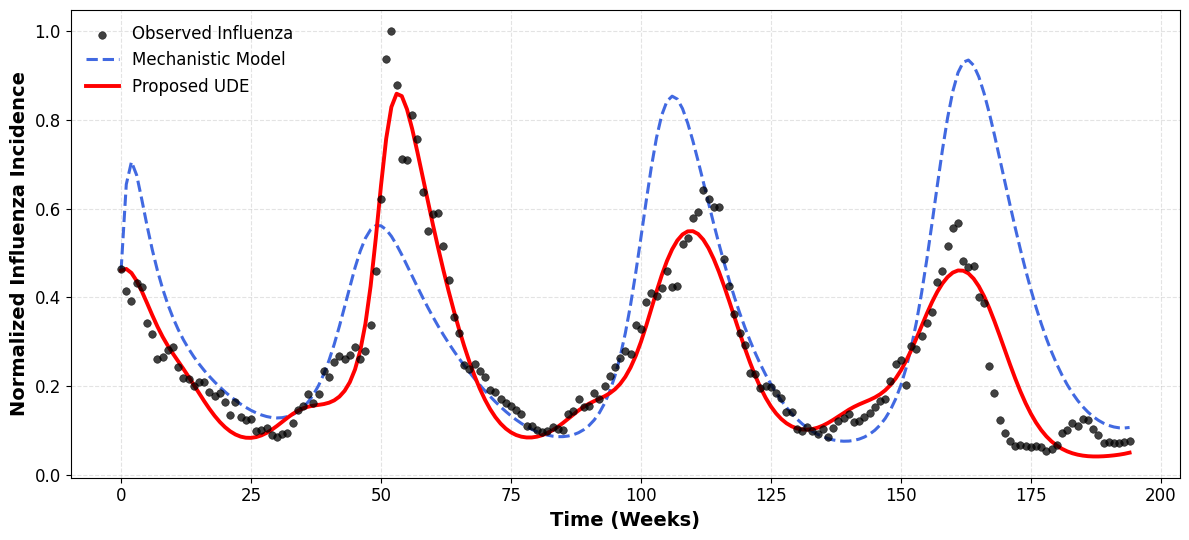

In [ ]:
# --------------------------------------------------
# BLOCK 10 : Visualization
# --------------------------------------------------
# mech_ode_func and I_mech already computed in Block 9.5 — reused here.

plt.figure(figsize=(12,5.5))

plt.scatter(t_data, I_obs, color="black", s=30, alpha=0.75,
            edgecolors="black", linewidth=0.4, label="Observed Influenza", zorder=3)

plt.plot(t_data, I_mech, "--", linewidth=2.2, color="royalblue", label="Mechanistic Model")

plt.plot(t_data, I_ude, "-", linewidth=2.8, color="red", label="Proposed UDE")

plt.xlabel("Time (Weeks)", fontsize=14, fontweight="bold")
plt.ylabel("Normalized Influenza Incidence", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(linestyle="--", alpha=0.35)
plt.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.savefig("Mechanistic_to_UDE_Comparison.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    return rmse, mae, smape

rmse_mech, mae_mech, smape_mech = compute_metrics(I_obs, I_mech)
rmse_ude_fin, mae_ude_fin, smape_ude_fin = compute_metrics(I_obs, I_ude_final)

refined_results = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "sMAPE"],
    "Original Mechanistic": [rmse_mech, mae_mech, smape_mech],
    "Refined UDE (Weighted)": [rmse_ude_fin, mae_ude_fin, smape_ude_fin],
    "Final Improvement (%)": [
        100*(rmse_mech - rmse_ude_fin)/rmse_mech,
        100*(mae_mech - mae_ude_fin)/mae_mech,
        100*(smape_mech - smape_ude_fin)/smape_mech
    ]
})

print("=== UPDATED PERFORMANCE COMPARISON (REFINED MODEL) ===")
print(refined_results.round(4).to_string(index=False))

=== UPDATED PERFORMANCE COMPARISON (REFINED MODEL) ===
Metric  Original Mechanistic  Refined UDE (Weighted)  Final Improvement (%)
  RMSE                0.1949                  0.0578                70.3601
   MAE                0.1268                  0.0427                66.2747
 sMAPE               37.2223                 22.5963                39.2938


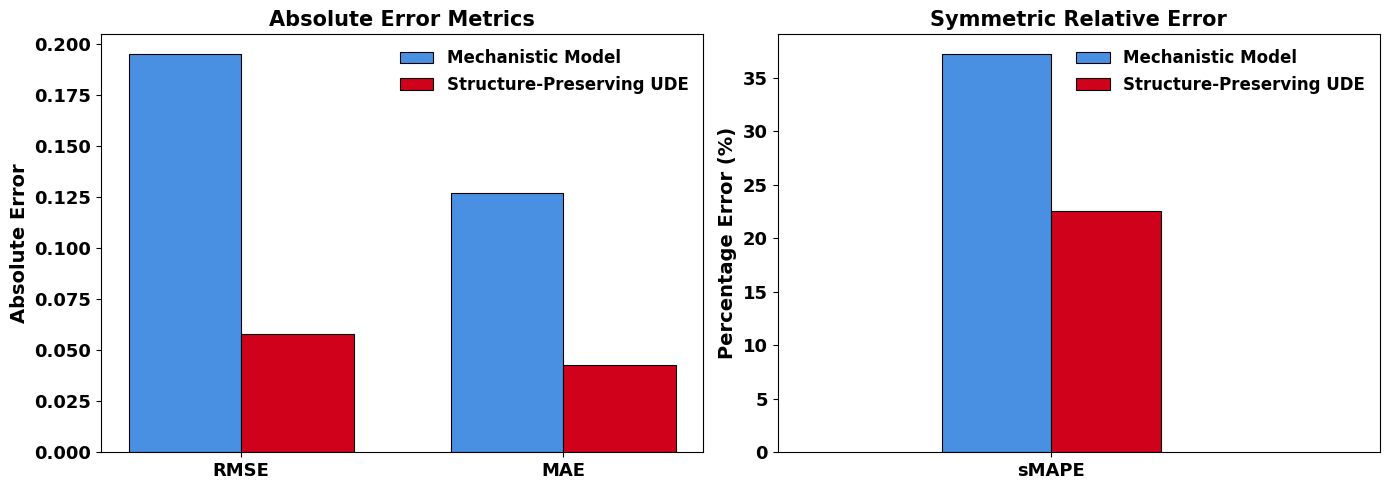

In [ ]:
metrics = refined_results["Metric"].values
mech = refined_results["Original Mechanistic"].values
ude = refined_results["Refined UDE (Weighted)"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

width = 0.35
x1 = np.arange(2)   # RMSE, MAE
x2 = np.arange(1)   # sMAPE only

ax1.bar(x1 - width/2, mech[0:2], width, label='Mechanistic Model', color='#4A90E2', edgecolor='black', linewidth=0.8)
ax1.bar(x1 + width/2, ude[0:2], width, label='Structure-Preserving UDE', color='#D0021B', edgecolor='black', linewidth=0.8)
ax1.set_ylabel('Absolute Error', fontsize=14, fontweight='bold')
ax1.set_xticks(x1)
ax1.set_xticklabels(['RMSE', 'MAE'], fontsize=13, fontweight='bold')
ax1.set_title('Absolute Error Metrics', loc='center', fontsize=15, fontweight='bold')
#ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.legend(frameon=False, prop={'size': 12, 'weight': 'bold'})

width_ax2 = 0.20 # Reduced width for the right panel
ax2.bar(x2 - width_ax2/2, mech[2:3], width_ax2, label='Mechanistic Model', color='#4A90E2', edgecolor='black', linewidth=0.8)
ax2.bar(x2 + width_ax2/2, ude[2:3], width_ax2, label='Structure-Preserving UDE', color='#D0021B', edgecolor='black', linewidth=0.8)
ax2.set_ylabel('Percentage Error (%)', fontsize=14, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(['sMAPE'], fontsize=13, fontweight='bold')
ax2.set_xlim(-0.5, 0.6)
ax2.set_title('Symmetric Relative Error', loc='center', fontsize=15, fontweight='bold')
#ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.legend(frameon=False, prop={'size': 12, 'weight': 'bold'}, loc='upper right')

# Make y-tick labels bold as well
ax1.tick_params(axis='y', labelsize=13)
for tick_label in ax1.get_yticklabels():
    tick_label.set_fontweight('bold')

ax2.tick_params(axis='y', labelsize=13)
for tick_label in ax2.get_yticklabels():
    tick_label.set_fontweight('bold')

plt.tight_layout()
plt.savefig("Publication_Two_Panel_Comparison.png", dpi=600, bbox_inches='tight')
plt.show()

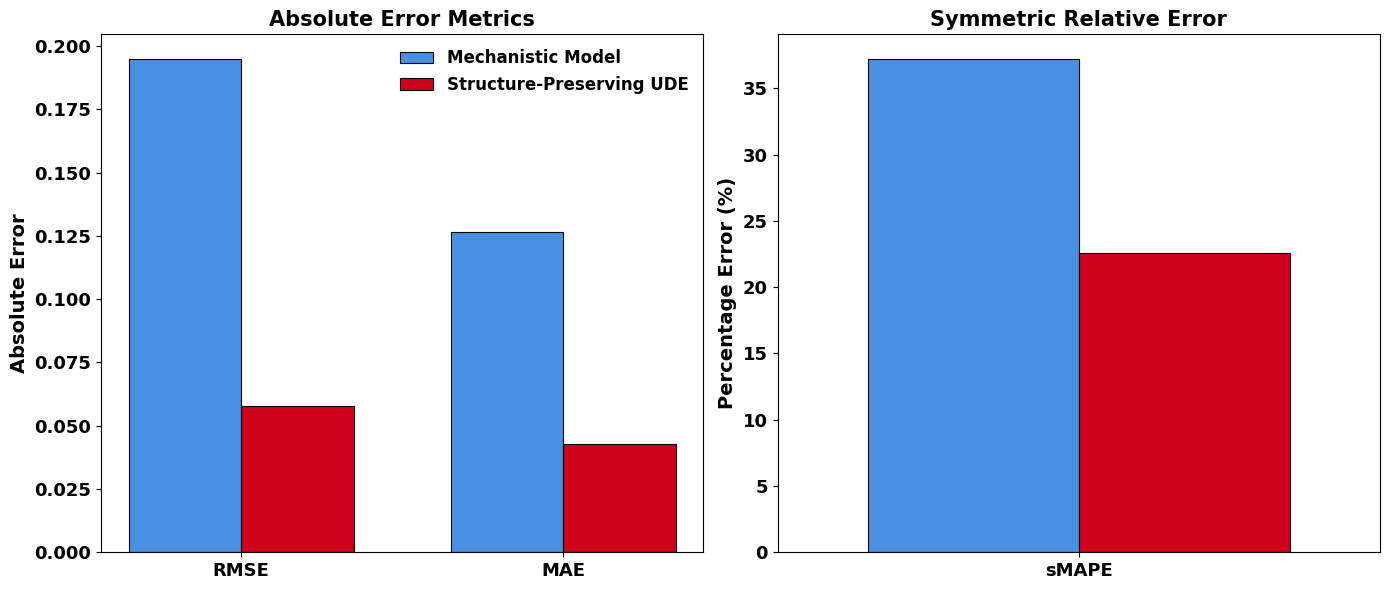

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metrics = refined_results["Metric"].values
mech = refined_results["Original Mechanistic"].values
ude = refined_results["Refined UDE (Weighted)"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

width = 0.35
x1 = np.arange(2)   # RMSE, MAE
x2 = np.arange(1)   # sMAPE only

ax1.bar(x1 - width/2, mech[0:2], width, label='Mechanistic Model', color='#4A90E2', edgecolor='black', linewidth=0.8)
ax1.bar(x1 + width/2, ude[0:2], width, label='Structure-Preserving UDE', color='#D0021B', edgecolor='black', linewidth=0.8)
ax1.set_ylabel('Absolute Error', fontsize=14, fontweight='bold')
ax1.set_xticks(x1)
ax1.set_xticklabels(['RMSE', 'MAE'], fontsize=13, fontweight='bold')
ax1.set_title('Absolute Error Metrics', loc='center', fontsize=15, fontweight='bold')
ax1.legend(frameon=False, prop={'size': 12, 'weight': 'bold'})

ax2.bar(x2 - width/2, mech[2:3], width, label='Mechanistic Model', color='#4A90E2', edgecolor='black', linewidth=0.8)
ax2.bar(x2 + width/2, ude[2:3], width, label='Structure-Preserving UDE', color='#D0021B', edgecolor='black', linewidth=0.8)
ax2.set_ylabel('Percentage Error (%)', fontsize=14, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(['sMAPE'], fontsize=13, fontweight='bold')
ax2.set_xlim(-0.5, 0.5)
ax2.set_title('Symmetric Relative Error', loc='center', fontsize=15, fontweight='bold')

# To make y-tick labels bold as well:
ax1.tick_params(axis='y', labelsize=13)
for tick_label in ax1.get_yticklabels():
    tick_label.set_fontweight('bold')

ax2.tick_params(axis='y', labelsize=13)
for tick_label in ax2.get_yticklabels():
    tick_label.set_fontweight('bold')

plt.tight_layout()
plt.savefig("Publication_Two_Panel_Comparison.png", dpi=600, bbox_inches='tight')
plt.show()

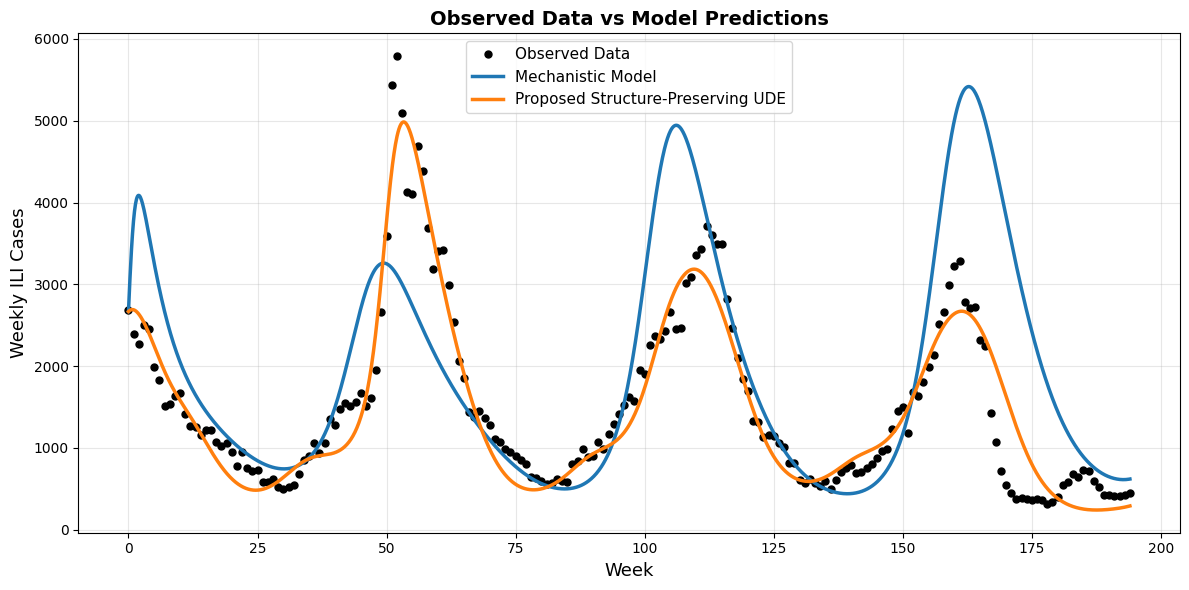

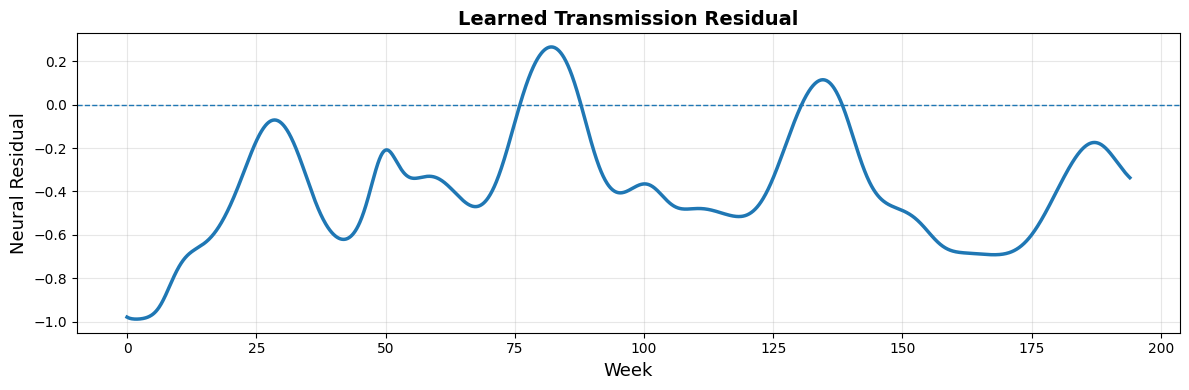

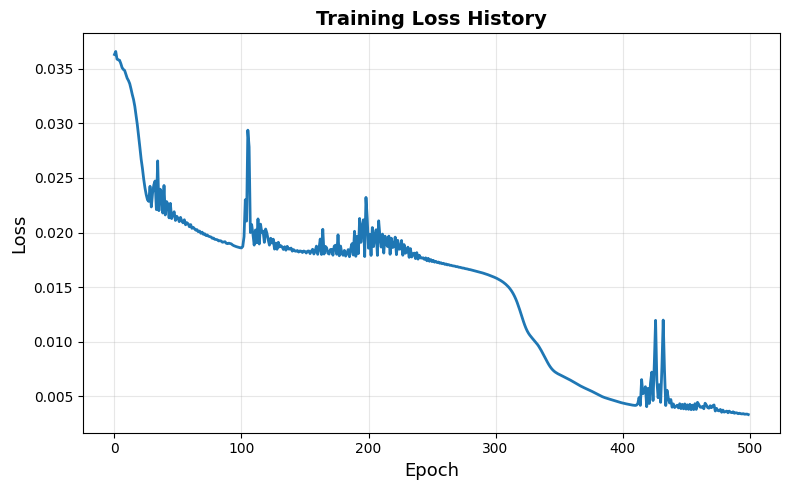

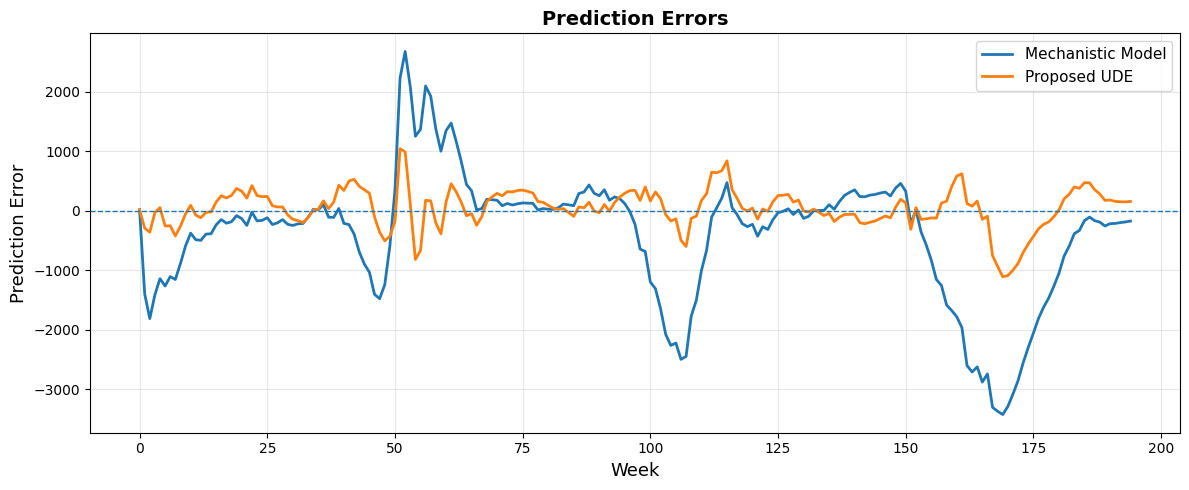

Workflow Completed Successfully
✓ Mechanistic Model Calibrated
✓ Structure-Preserving UDE Trained
✓ Predictions Generated
✓ Performance Evaluated
✓ Figures Created


In [ ]:
# ==========================================================
# Block 12 : Additional Visualizations
# ==========================================================

import matplotlib.pyplot as plt

plt.style.use("default")

# ----------------------------------------------------------
# Figure 1 : Observed vs Model Predictions
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(t_data, observed_actual, "ko", markersize=5, label="Observed Data")
plt.plot(t_fine, I_mech_actual, linewidth=2.5, label="Mechanistic Model")
plt.plot(t_fine, I_ude_actual, linewidth=2.5, label="Proposed Structure-Preserving UDE")

plt.xlabel("Week", fontsize=13)
plt.ylabel("Weekly ILI Cases", fontsize=13)
plt.title("Observed Data vs Model Predictions", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Figure 2 : Residual Correction
# ----------------------------------------------------------

with torch.no_grad():
    residual = seasonal_residual_nn(
        ude_prediction[:,0,:],
        t_fine_tensor.unsqueeze(1)
    )

residual = residual.cpu().numpy().flatten()

plt.figure(figsize=(12,4))
plt.plot(t_fine, residual, linewidth=2.5)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Week", fontsize=13)
plt.ylabel("Neural Residual", fontsize=13)
plt.title("Learned Transmission Residual", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Figure 3 : Training Loss
# ----------------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(loss_history, linewidth=2)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)
plt.title("Training Loss History", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Figure 4 : Prediction Errors
# ----------------------------------------------------------

error_mech = observed_actual - I_mech_obs_actual
error_ude = observed_actual - I_ude_obs_actual

plt.figure(figsize=(12,5))
plt.plot(t_data, error_mech, linewidth=2, label="Mechanistic Model")
plt.plot(t_data, error_ude, linewidth=2, label="Proposed UDE")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Week", fontsize=13)
plt.ylabel("Prediction Error", fontsize=13)
plt.title("Prediction Errors", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("="*70)
print("Workflow Completed Successfully")
print("="*70)
print("✓ Mechanistic Model Calibrated")
print("✓ Structure-Preserving UDE Trained")
print("✓ Predictions Generated")
print("✓ Performance Evaluated")
print("✓ Figures Created")
print("="*70)

Block 13: Learned Transmission Rate — Baseline vs Effective β(t)

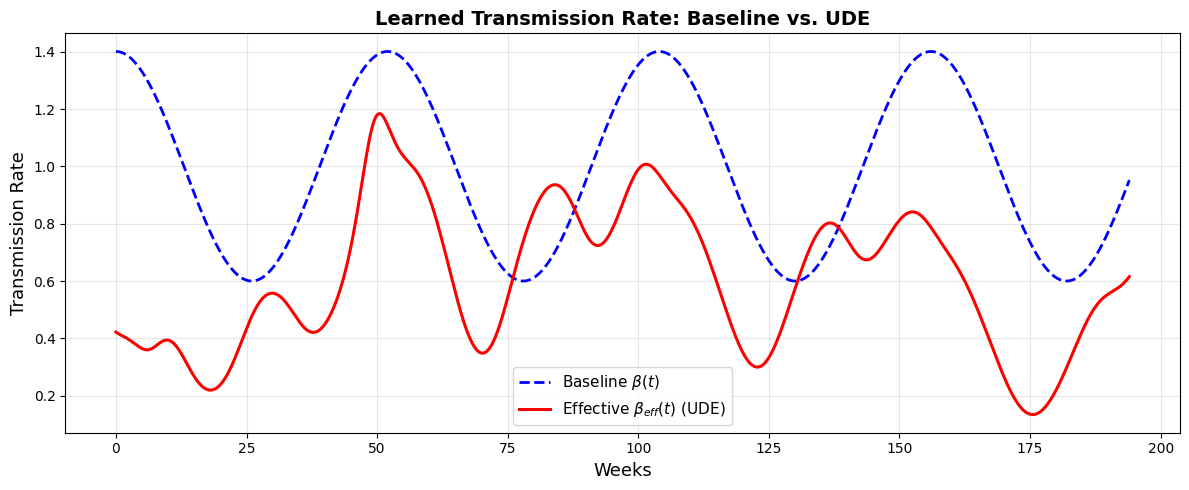

Mean residual correction to beta: -0.3811


In [ ]:
# --------------------------------------------------
# BLOCK 13 : Learned Transmission Rate (Baseline vs Effective)
# --------------------------------------------------

seasonal_residual_nn.eval()

with torch.no_grad():
    beta_base_fine = params["beta0"] * (1.0 + params["amp"] * np.cos(2 * np.pi * t_fine / 52))

    # Effective beta computed using the ACTUAL trajectory state at each time point
    # (more accurate than evaluating at a single fixed state)
    S_traj = ude_prediction[:, 0, 0].cpu().numpy()
    I_traj = ude_prediction[:, 0, 1].cpu().numpy()
    R_traj = ude_prediction[:, 0, 2].cpu().numpy()

    beta_eff_fine = []
    for i in range(len(t_fine)):
        X_state = ude_prediction[i:i+1, 0, :]          # [1,3] state at time i
        t_val = t_fine_tensor[i:i+1].view(1, 1)
        res = seasonal_residual_nn(X_state, t_val).item()
        b_eff = beta_base_fine[i] + res
        b_eff = np.clip(b_eff, 0.02, 5.0)               # match training clamp
        beta_eff_fine.append(b_eff)

beta_eff_fine = np.array(beta_eff_fine)

plt.figure(figsize=(12, 5))
plt.plot(t_fine, beta_base_fine, "b--", linewidth=2, label=r"Baseline $\beta(t)$")
plt.plot(t_fine, beta_eff_fine, "r-", linewidth=2.2, label=r"Effective $\beta_{eff}(t)$ (UDE)")
plt.title("Learned Transmission Rate: Baseline vs. UDE", fontsize=14, fontweight="bold")
plt.xlabel("Weeks", fontsize=13)
plt.ylabel("Transmission Rate", fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean residual correction to beta: {np.mean(beta_eff_fine - beta_base_fine):+.4f}")

Block 14: Effective Reproduction Number R_e(t)

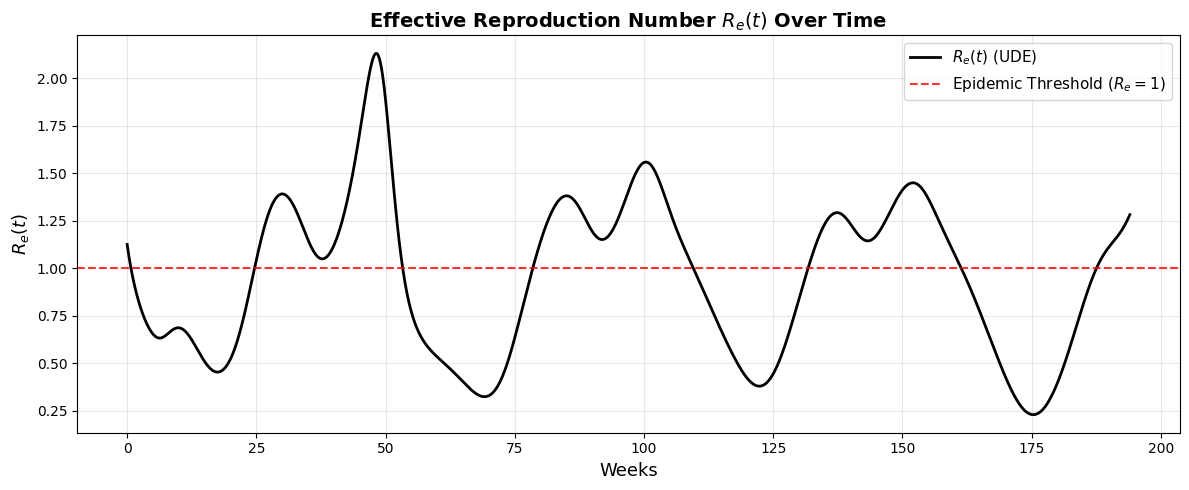

Weeks above epidemic threshold (R_e > 1): 997 / 2000


In [ ]:
# --------------------------------------------------
# BLOCK 14 : Effective Reproduction Number R_e(t)
# --------------------------------------------------

seasonal_residual_nn.eval()

with torch.no_grad():
    Re_t = []
    for i in range(len(t_fine)):
        X_state = ude_prediction[i:i+1, 0, :]
        S, I, R = X_state[0, 0].item(), X_state[0, 1].item(), X_state[0, 2].item()
        N = S + I + R + 1e-8

        t_val = t_fine_tensor[i:i+1].view(1, 1)
        beta_base = params["beta0"] * (1.0 + params["amp"] * np.cos(2 * np.pi * t_fine[i] / 52))
        res = seasonal_residual_nn(X_state, t_val).item()
        beta_eff = np.clip(beta_base + res, 0.02, 5.0)

        recovery_rate = (params["mu"] + params["alpha"] + params["delta"]
                          + params["C"] / (1 + params["d"] * I))
        Re = (beta_eff / recovery_rate) * (S / N)
        Re_t.append(Re)

Re_t = np.array(Re_t)

plt.figure(figsize=(12, 5))
plt.plot(t_fine, Re_t, "k-", linewidth=2, label=r"$R_e(t)$ (UDE)")
plt.axhline(1, color="red", linestyle="--", alpha=0.8, label="Epidemic Threshold ($R_e=1$)")
plt.title("Effective Reproduction Number $R_e(t)$ Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Weeks", fontsize=13)
plt.ylabel("$R_e(t)$", fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Weeks above epidemic threshold (R_e > 1): {np.sum(Re_t > 1)} / {len(Re_t)}")

Block 15: Phase Portraits (S vs I, I vs R)

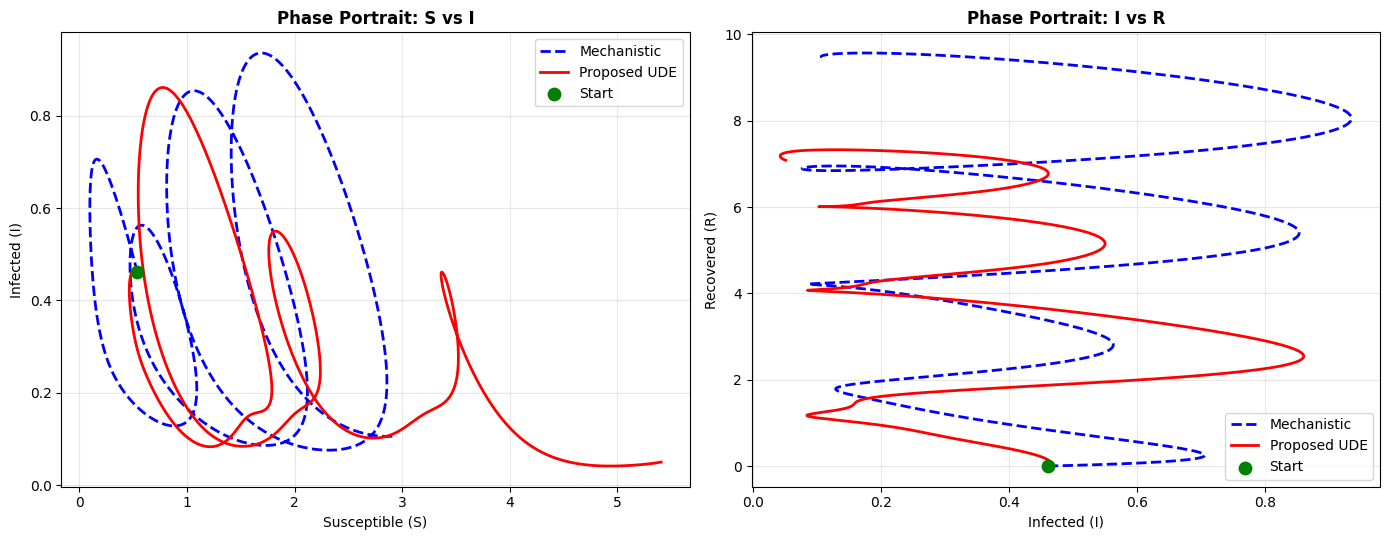

In [ ]:
# --------------------------------------------------
# BLOCK 15 : Phase Portraits
# --------------------------------------------------

S_mech = mech_prediction[:, 0].cpu().numpy()
I_mech_traj = mech_prediction[:, 1].cpu().numpy()
R_mech = mech_prediction[:, 2].cpu().numpy()

S_ude = ude_prediction[:, 0, 0].cpu().numpy()
I_ude_traj = ude_prediction[:, 0, 1].cpu().numpy()
R_ude = ude_prediction[:, 0, 2].cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

ax[0].plot(S_mech, I_mech_traj, "b--", linewidth=2, label="Mechanistic")
ax[0].plot(S_ude, I_ude_traj, "r-", linewidth=2, label="Proposed UDE")
ax[0].scatter(S_ude[0], I_ude_traj[0], color="green", s=80, zorder=5, label="Start")
ax[0].set_title("Phase Portrait: S vs I", fontweight="bold")
ax[0].set_xlabel("Susceptible (S)")
ax[0].set_ylabel("Infected (I)")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(I_mech_traj, R_mech, "b--", linewidth=2, label="Mechanistic")
ax[1].plot(I_ude_traj, R_ude, "r-", linewidth=2, label="Proposed UDE")
ax[1].scatter(I_ude_traj[0], R_ude[0], color="green", s=80, zorder=5, label="Start")
ax[1].set_title("Phase Portrait: I vs R", fontweight="bold")
ax[1].set_xlabel("Infected (I)")
ax[1].set_ylabel("Recovered (R)")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Block 16: Neural Correction Sensitivity Analysis

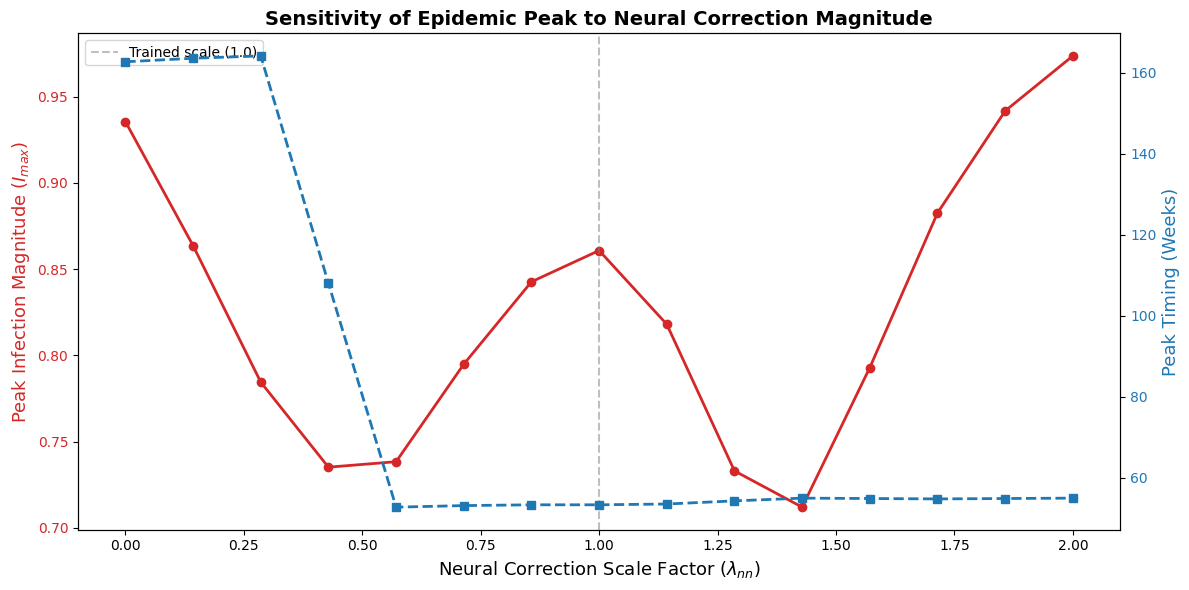

In [ ]:
# --------------------------------------------------
# BLOCK 16 : Neural Correction Sensitivity Analysis
# --------------------------------------------------
# How much does scaling the NN's correction change the predicted peak
# magnitude and timing? Uses the REAL trained model integrated with
# torchdiffeq (not a manual Euler loop), so results reflect the actual dynamics.

class ScaledODEFunc(nn.Module):
    def __init__(self, model, params, scale):
        super().__init__()
        self.model = model
        self.params = params
        self.scale = scale

    def forward(self, t, X):
        S, I, R = X[:,0:1], X[:,1:2], X[:,2:3]
        beta = self.params["beta0"] * (1 + self.params["amp"] * torch.cos(2 * math.pi * t / 52))
        t_input = torch.ones_like(S) * t
        residual = self.scale * self.model(X, t_input)
        beta = torch.clamp(beta + residual, 0.02, 5.0)
        N = S + I + R + 1e-8
        dS = self.params["Lambda"] - beta*S*I/N - (self.params["mu"]+self.params["nu"])*S + self.params["omega"]*R
        dI = beta*S*I/N - (self.params["mu"]+self.params["alpha"]+self.params["delta"])*I - (self.params["C"]*I)/(1+self.params["d"]*I)
        dR = self.params["alpha"]*I - (self.params["mu"]+self.params["omega"])*R + self.params["nu"]*S + (self.params["C"]*I)/(1+self.params["d"]*I)
        return torch.cat([dS,dI,dR],dim=1)

seasonal_residual_nn.eval()

nn_scales = np.linspace(0.0, 2.0, 15)
peak_magnitudes = []
peak_weeks = []

with torch.no_grad():
    for scale in nn_scales:
        scaled_func = ScaledODEFunc(seasonal_residual_nn, params, scale).to(device)
        pred = odeint(scaled_func, X0, t_fine_tensor, method="rk4")
        if pred.dim() == 3: pred = pred.squeeze(1)
        I_traj = pred[:, 1].cpu().numpy()
        peak_magnitudes.append(np.max(I_traj))
        peak_weeks.append(t_fine[np.argmax(I_traj)])

fig, ax1 = plt.subplots(figsize=(12, 6))

color = "tab:red"
ax1.set_xlabel(r"Neural Correction Scale Factor ($\lambda_{nn}$)", fontsize=13)
ax1.set_ylabel("Peak Infection Magnitude ($I_{max}$)", color=color, fontsize=13)
ax1.plot(nn_scales, peak_magnitudes, color=color, linewidth=2, marker="o")
ax1.tick_params(axis="y", labelcolor=color)
ax1.axvline(1.0, color="gray", linestyle="--", alpha=0.5, label="Trained scale (1.0)")

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("Peak Timing (Weeks)", color=color, fontsize=13)
ax2.plot(nn_scales, peak_weeks, color=color, linewidth=2, linestyle="--", marker="s")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Sensitivity of Epidemic Peak to Neural Correction Magnitude", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", fontsize=10)
fig.tight_layout()
plt.show()

Block 17: Multi-Region Data Preparation

In [ ]:
import os

# --------------------------------------------------
# BLOCK 17 (REVISED) : Real Regional Data — Config & Loading
# --------------------------------------------------

REGION_FILES = {
    "Bay Area":     "/content/Bay_Area.csv",
    "Central": "/content/Central.csv",
    "Northern":   "/content/Northern.csv",
    "Upper Southern":   "/content/Upper_Southern.csv",
    "Lower Sourthen":   "/content/Lower_Southern.csv",
}
# EDIT the paths above to match your actual filenames.
# Each file is assumed to have the SAME columns as California.csv:
#   a date column named "weekending" and a count column named "Total_ILI".
# If your columns are named differently, change DATE_COL / VALUE_COL below.

DATE_COL = "weekending"
VALUE_COL = "Total_ILI"

region_data = {}

for name, path in REGION_FILES.items():
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing regional file for '{name}': {path}\n"
            f"Update REGION_FILES with the correct path before continuing."
        )
    df_r = pd.read_csv(path)
    df_r[DATE_COL] = pd.to_datetime(df_r[DATE_COL], format="mixed")
    df_r = df_r.sort_values(DATE_COL).reset_index(drop=True)

    t_r = (df_r[DATE_COL] - df_r[DATE_COL].iloc[0]).dt.days.values / 7
    I_r = df_r[VALUE_COL].values.astype(np.float32)
    I_r = I_r / np.max(I_r)

    region_data[name] = {"t": t_r.astype(np.float32), "I": I_r}

print("Loaded regional data:")
for name, d in region_data.items():
    print(f"  {name:8s}: {len(d['I'])} weeks, range [{d['I'].min():.3f}, {d['I'].max():.3f}]")

Loaded regional data:
  Bay Area: 195 weeks, range [0.115, 1.000]
  Central : 195 weeks, range [0.000, 1.000]
  Northern: 195 weeks, range [0.007, 1.000]
  Upper Southern: 195 weeks, range [0.000, 1.000]
  Lower Sourthen: 195 weeks, range [0.010, 1.000]


Insert a new cell between these two — after data loads, before any training happens. This is Block 17.5:

In [ ]:
# --------------------------------------------------
# BLOCK 17.5 : Verify Zero-Value Meaning & Handle Missing Data
# Runs AFTER Block 17 (raw data loaded into region_data), BEFORE Block 18
# (no training happens until this is resolved).
# --------------------------------------------------
# --------------------------------------------------
# Snapshot UNTRUNCATED region data, before Block 17.5's truncation is applied.
# Needed for the supplementary "why we truncated" comparison figure.
# --------------------------------------------------
import copy as _copy_module
region_data_untruncated = _copy_module.deepcopy(region_data)
print("Snapshotted untruncated region_data for supplementary comparison figure.")

def diagnose_zeros(name, t_arr, I_arr, zero_tol=1e-6):
    """Reports whether zeros are isolated (possibly real) or a contiguous
    block (almost certainly a reporting gap)."""
    is_zero = np.abs(I_arr) <= zero_tol
    n_zeros = is_zero.sum()
    if n_zeros == 0:
        print(f"  {name}: no zero values.")
        return

    zero_idx = np.where(is_zero)[0]
    gaps = np.diff(zero_idx)
    runs = np.split(zero_idx, np.where(gaps != 1)[0] + 1)
    run_lengths = sorted([len(r) for r in runs], reverse=True)

    print(f"  {name}: {n_zeros}/{len(I_arr)} zero values "
          f"({100*n_zeros/len(I_arr):.1f}%), longest contiguous run = {run_lengths[0]} weeks")
    if run_lengths[0] >= 10:
        print(f"    -> Long contiguous run detected: treat as a REPORTING GAP, not a real low.")
    else:
        print(f"    -> Zeros are scattered/short: may be genuine low-incidence weeks.")

print("=== Zero-value diagnostics (all regions) ===")
for name, d in region_data.items():
    diagnose_zeros(name, d["t"], d["I"])

# --------------------------------------------------
# Fix: Truncate trailing zero-block (most likely case for Central)
# --------------------------------------------------
def truncate_trailing_zero_block(t_arr, I_arr, min_run_length=10, zero_tol=1e-6):
    """Finds the first contiguous zero-run of at least min_run_length weeks
    and truncates the series there. Returns the trimmed series and the
    week index where truncation occurred (or None if no such run exists)."""
    is_zero = np.abs(I_arr) <= zero_tol
    n = len(I_arr)
    i = 0
    while i < n:
        if is_zero[i]:
            j = i
            while j < n and is_zero[j]:
                j += 1
            run_len = j - i
            if run_len >= min_run_length:
                return t_arr[:i], I_arr[:i], t_arr[i]
            i = j
        else:
            i += 1
    return t_arr, I_arr, None   # no qualifying gap found

t_central, I_central = region_data["Central"]["t"], region_data["Central"]["I"]
t_trim, I_trim, gap_start = truncate_trailing_zero_block(t_central, I_central)

if gap_start is not None:
    print(f"\nCentral: truncating at week {gap_start:.0f} "
          f"(dropped {len(I_central) - len(I_trim)} trailing weeks of zero/near-zero reporting)")
    region_data["Central"]["t"] = t_trim
    region_data["Central"]["I"] = I_trim / np.max(I_trim)   # renormalize after truncation
else:
    print("\nCentral: no qualifying trailing zero-block found — investigate manually.")

print("\nFinal region lengths after zero-handling:")
for name, d in region_data.items():
    print(f"  {name:8s}: {len(d['I'])} weeks")

Snapshotted untruncated region_data for supplementary comparison figure.
=== Zero-value diagnostics (all regions) ===
  Bay Area: no zero values.
  Central: 15/195 zero values (7.7%), longest contiguous run = 9 weeks
    -> Zeros are scattered/short: may be genuine low-incidence weeks.
  Northern: no zero values.
  Upper Southern: 3/195 zero values (1.5%), longest contiguous run = 1 weeks
    -> Zeros are scattered/short: may be genuine low-incidence weeks.
  Lower Sourthen: no zero values.

Central: no qualifying trailing zero-block found — investigate manually.

Final region lengths after zero-handling:
  Bay Area: 195 weeks
  Central : 195 weeks
  Northern: 195 weeks
  Upper Southern: 195 weeks
  Lower Sourthen: 195 weeks


Block 18: Regularized UDE Training Function

In [ ]:
# --------------------------------------------------
# BLOCK 18 : Regularized UDE Training Function
# L(phi) = L_data + lambda_r * L_reg   (Eqs. 15-17 in the paper)
# --------------------------------------------------

def train_ude_regularized(t_arr, I_arr, params, lam_r=1e-3, epochs=300,
                           lr=5e-4, seed=None, init_state_dict=None, verbose=False):
    """
    Trains a SeasonalResidualNN + ODEFunc on a given (t, I) series with
    residual regularization strength lam_r.
    Returns: model, ode_func, X0_local, t_tensor_local, loss_history
    """
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    I0_l = I_arr[0]
    R0_l = 0.0
    S0_l = 1.0 - I0_l - R0_l
    X0_local = torch.tensor([[S0_l, I0_l, R0_l]], dtype=torch.float32, device=device)

    t_tensor_local = torch.tensor(t_arr, dtype=torch.float32, device=device)
    I_tensor_local = torch.tensor(I_arr, dtype=torch.float32, device=device)

    local_model = SeasonalResidualNN().to(device)
    if init_state_dict is not None:
        local_model.load_state_dict(copy.deepcopy(init_state_dict))

    local_ode_func = ODEFunc(local_model, params).to(device)
    optimizer_l = optim.AdamW(local_model.parameters(), lr=lr, weight_decay=1e-5)

    loss_hist = []

    for epoch in range(epochs):
        optimizer_l.zero_grad()

        pred_X = odeint(local_ode_func, X0_local, t_tensor_local, method="rk4")
        if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)

        loss_data = F.mse_loss(pred_X[:, 1], I_tensor_local)

        # --- Residual regularization: penalize |delta_beta_phi(S,I,R)| ---
        with torch.enable_grad():
            beta_base = params["beta0"] * (1 + params["amp"] *
                         torch.cos(2 * math.pi * t_tensor_local.unsqueeze(1) / 52))
            residual = local_model(pred_X, t_tensor_local.unsqueeze(1))
            loss_reg = torch.mean(residual ** 2)

        loss = loss_data + lam_r * loss_reg
        loss.backward()
        torch.nn.utils.clip_grad_norm_(local_model.parameters(), 1.0)
        optimizer_l.step()

        loss_hist.append(loss.item())
        if verbose and epoch % 50 == 0:
            print(f"    Epoch {epoch:3d} | Loss={loss.item():.6f} | "
                  f"L_data={loss_data.item():.6f} | L_reg={loss_reg.item():.6f}")

    return local_model, local_ode_func, X0_local, t_tensor_local, loss_hist


import copy
print("train_ude_regularized() defined.")

train_ude_regularized() defined.


Block 19: Multi-Region Source Pretraining

In [ ]:
# --------------------------------------------------
# BLOCK 19 : Multi-Region Source Pretraining
# Pretrain a shared residual model phi* on POOLED source regions
# --------------------------------------------------

def pretrain_source_model(source_names, params, lam_r=1e-3, epochs=300, seed=0):
    """Pools the (t, I) series of all source regions into one combined
    training set and trains a shared SeasonalResidualNN on it."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    pooled_model = SeasonalResidualNN().to(device)
    pooled_optimizer = optim.AdamW(pooled_model.parameters(), lr=5e-4, weight_decay=1e-5)
    loss_hist = []

    # Pre-build per-region tensors
    region_tensors = {}
    for name in source_names:
        d = region_data[name]
        I0_r, R0_r = d["I"][0], 0.0
        S0_r = 1.0 - I0_r - R0_r
        X0_r = torch.tensor([[S0_r, I0_r, R0_r]], dtype=torch.float32, device=device)
        t_r = torch.tensor(d["t"], dtype=torch.float32, device=device)
        I_r = torch.tensor(d["I"], dtype=torch.float32, device=device)
        region_tensors[name] = (X0_r, t_r, I_r)

    for epoch in range(epochs):
        pooled_optimizer.zero_grad()
        total_loss = 0.0

        for name in source_names:
            X0_r, t_r, I_r = region_tensors[name]
            ode_func_r = ODEFunc(pooled_model, params).to(device)
            pred_X = odeint(ode_func_r, X0_r, t_r, method="rk4")
            if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)

            loss_data = F.mse_loss(pred_X[:, 1], I_r)
            residual = pooled_model(pred_X, t_r.unsqueeze(1))
            loss_reg = torch.mean(residual ** 2)

            total_loss = total_loss + loss_data + lam_r * loss_reg

        total_loss = total_loss / len(source_names)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(pooled_model.parameters(), 1.0)
        pooled_optimizer.step()

        loss_hist.append(total_loss.item())
        if epoch % 50 == 0:
            print(f"  [Source Pretrain] Epoch {epoch:3d} | Pooled Loss: {total_loss.item():.6f}")

    return pooled_model, loss_hist

Block 20 (revised): LORO with fixed split + real ensemble diversity

Block 20: LORO — 75/25 Chronological Split with Ensemble Diversity (Untruncated Data)

In [ ]:
import copy

# --------------------------------------------------
# BLOCK 20 (UNIFIED) : LORO — 75/25 Chronological Split + Genuine Ensemble CI
# Runs once, on UNTRUNCATED data only (the truncated pass was removed to
# cut training time -- see note below).
# --------------------------------------------------

TRAIN_FRACTION = 0.75      # 75/25 chronological split, per-region
LAM_R = 1e-3
SOURCE_EPOCHS = 200
FINETUNE_EPOCHS = 150
N_ENSEMBLE = 8
WEIGHT_NOISE_SCALE = 0.02
SUBSAMPLE_FRAC = 0.85

def perturb_state_dict(state_dict, noise_scale, seed):
    torch.manual_seed(seed)
    perturbed = {}
    for k, v in state_dict.items():
        perturbed[k] = v + torch.randn_like(v) * noise_scale
    return perturbed

def subsample_weeks(t_arr, I_arr, frac, seed):
    rng = np.random.RandomState(seed)
    n = len(t_arr)
    k = max(8, int(n * frac))
    idx = np.sort(rng.choice(n, size=k, replace=False))
    return t_arr[idx], I_arr[idx]

def compute_metrics_arr(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    smape = np.mean(2*np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    return rmse, mae, mape, smape


def run_loro(data_dict, region_key_name="Region", tag=""):
    """
    Runs the full LORO (leave-one-region-out) transfer-learning + ensemble
    procedure on any {region_name: {"t":..., "I":...}} dict.

    data_dict       : region_data OR region_data_untruncated
    region_key_name : column name used in the returned results DataFrame
                      (used consistently as "Region" for both truncated and untruncated data) —
                      kept configurable so downstream plotting code
                      (Block 21 / 21u) doesn't need to change.
    tag             : optional label used only in printed progress messages.

    Returns
    -------
    results_df  : per-region metrics DataFrame (+ Average row)
    predictions : {region_name: {t, obs, split_idx, split_week, pred_mean, ci_lo, ci_hi, ensemble_state_dicts}}
    """
    names = list(data_dict.keys())
    results = []
    predictions = {}

    for target_name in names:
        print(f"\n=== {tag}Target Region: {target_name} ===")
        source_names = [n for n in names if n != target_name]

        d = data_dict[target_name]
        t_full = d["t"]
        I_full = d["I"]
        n_total = len(I_full)

        # --- 75/25 chronological split (not a fixed absolute week) ---
        split_idx = int(round(n_total * TRAIN_FRACTION))
        split_idx = max(10, min(split_idx, n_total - 5))   # guard: both sides need enough points
        split_week = t_full[split_idx]
        n_train = split_idx
        n_test = n_total - split_idx

        print(f"  Split: {n_train} training weeks / {n_test} testing weeks "
              f"({n_train}/{n_total} = {100*n_train/n_total:.1f}% train)")

        t_train, I_train = t_full[:split_idx], I_full[:split_idx]

        # --- Step 1: Pretrain shared residual on SOURCE regions ---
        phi_star, _ = pretrain_source_model(source_names, params, lam_r=LAM_R,
                                             epochs=SOURCE_EPOCHS, seed=1234)
        phi_star_state = phi_star.state_dict()

        # --- Step 2: Genuinely diverse ensemble fine-tune on TRAIN portion ---
        ensemble_preds = []
        ensemble_state_dicts_for_region = [] # Store state_dicts for prospective forecast
        for seed in range(N_ENSEMBLE):
            t_sub, I_sub = subsample_weeks(t_train, I_train, SUBSAMPLE_FRAC, seed)
            perturbed_init = perturb_state_dict(phi_star_state, WEIGHT_NOISE_SCALE, seed)

            model_e, ode_func_e, X0_e, _, _ = train_ude_regularized(
                t_sub, I_sub, params, lam_r=LAM_R, epochs=FINETUNE_EPOCHS,
                lr=3e-4, seed=seed, init_state_dict=perturbed_init
            )
            model_e.eval()
            with torch.no_grad():
                t_full_tensor = torch.tensor(t_full, dtype=torch.float32, device=device)
                pred_X = odeint(ode_func_e, X0_e, t_full_tensor, method="dopri5")
                if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)
                ensemble_preds.append(pred_X[:, 1].cpu().numpy())
            ensemble_state_dicts_for_region.append(copy.deepcopy(model_e.state_dict())) # Save deep copy

        ensemble_preds = np.stack(ensemble_preds, axis=0)
        pred_mean = ensemble_preds.mean(axis=0)
        pred_std = ensemble_preds.std(axis=0)
        ci_lo = np.maximum(pred_mean - 1.96 * pred_std, 0.0)
        ci_hi = pred_mean + 1.96 * pred_std

        print(f"  Ensemble spread check — mean std across forecast weeks: "
              f"{pred_std[split_idx:].mean():.5f}  (should be clearly > 0)")

        # --- Held-out RMSE/MAE/MAPE/sMAPE on the ACTUAL held-out 25% only ---
        obs_forecast = I_full[split_idx:]
        pred_forecast = pred_mean[split_idx:]
        rmse_f, mae_f, mape_f, smape_f = compute_metrics_arr(obs_forecast, pred_forecast)

        results.append({
            region_key_name: target_name, "N_train": n_train, "N_test": n_test,
            "Split Week": split_week, "RMSE": rmse_f, "MAE": mae_f,
            "MAPE (%)": mape_f, "sMAPE (%)": smape_f
        })
        predictions[target_name] = {
            "t": t_full, "obs": I_full, "split_idx": split_idx, "split_week": split_week,
            "pred_mean": pred_mean, "ci_lo": ci_lo, "ci_hi": ci_hi,
            "ensemble_state_dicts": ensemble_state_dicts_for_region # Add this
        }

        print(f"  {tag}Held-out RMSE={rmse_f:.4f} MAE={mae_f:.4f} MAPE={mape_f:.2f}% sMAPE={smape_f:.2f}%")

    results_df = pd.DataFrame(results)
    avg_row = results_df.mean(numeric_only=True).to_dict()
    avg_row[region_key_name] = "Average"
    results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

    print(f"\n--- {tag}Held-Out (75/25) Forecast Performance ---")
    print(results_df.round(4).to_string(index=False))

    return results_df, predictions


# --------------------------------------------------
# Run: UNTRUNCATED data only.
# The truncated pass has been removed on request -- it duplicated a full
# LORO training run (5 regions x 8-member ensemble each) purely to produce
# a figure that is no longer used, roughly doubling this block's runtime
# for no benefit now that only the untruncated figures are kept.
# --------------------------------------------------
region_names = list(region_data_untruncated.keys())
main_results_untruncated_df, main_predictions_untruncated = run_loro(
    region_data_untruncated, region_key_name="Region", tag="[UNTRUNCATED] "
)


=== [UNTRUNCATED] Target Region: Bay Area ===
  Split: 146 training weeks / 49 testing weeks (146/195 = 74.9% train)
  [Source Pretrain] Epoch   0 | Pooled Loss: 0.057163
  [Source Pretrain] Epoch  50 | Pooled Loss: 0.040741
  [Source Pretrain] Epoch 100 | Pooled Loss: 0.017124
  [Source Pretrain] Epoch 150 | Pooled Loss: 0.016136
  Ensemble spread check — mean std across forecast weeks: 0.04628  (should be clearly > 0)
  [UNTRUNCATED] Held-out RMSE=0.1700 MAE=0.1354 MAPE=67.67% sMAPE=41.79%

=== [UNTRUNCATED] Target Region: Central ===
  Split: 146 training weeks / 49 testing weeks (146/195 = 74.9% train)
  [Source Pretrain] Epoch   0 | Pooled Loss: 0.048033
  [Source Pretrain] Epoch  50 | Pooled Loss: 0.034902
  [Source Pretrain] Epoch 100 | Pooled Loss: 0.030112
  [Source Pretrain] Epoch 150 | Pooled Loss: 0.022475
  Ensemble spread check — mean std across forecast weeks: 0.05506  (should be clearly > 0)
  [UNTRUNCATED] Held-out RMSE=0.3683 MAE=0.2886 MAPE=392344384.00% sMAPE=180.6

Block 21/22 (Shared): 5-row plotting function used by Figure 3 (LORO) and Figure 4 (Prospective)

In [ ]:
# --------------------------------------------------
# BLOCK 21/23 (UNIFIED PLOTTING) : Shared 5-row regional forecast plotter
# --------------------------------------------------
# WHY THIS CELL EXISTS
# Blocks 21, 21u, 23 and 23u each reimplemented the same drawing logic
# (period shading -> scatter -> UDE line -> uncertainty band -> boundary
# line -> legend) with tiny copy/paste differences. That duplication is
# exactly why the four figures had drifted out of sync: Fig. 4 was still
# a 3-column grid while Fig. S1/S2 were already a 5-row stack, and the
# legend still said "95% CI" in some panels after being renamed in
# others. This cell defines ONE function used by all four figures below,
# so every panel (LORO or prospective, truncated or untruncated) is
# guaranteed to share the same 5-row layout and the same legend wording.
#
# REVISED:
#   - Removed the light-gray shading before the train/forecast boundary
#     (only the post-boundary shading — held-out / prospective period —
#     is kept).
#   - Legend is no longer drawn per-panel. A single shared legend is
#     drawn once, below the bottom panel, wrapped into two rows.
# --------------------------------------------------

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd


def plot_regional_forecast_panels(
    region_order,
    predictions,
    mode,                        # "loro"  or  "prospective"
    results_df=None,             # required for mode="loro" (RMSE in titles)
    region_key_name="Region",  # "Region" (truncated) or "Region" (untruncated)
    suptitle="",
    save_path=None,
    ensemble_label="95% Ensemble Interval",   # <-- "CI" renamed everywhere, in one place
    figsize_per_row=4.2,
    fig_width=11,
):
    """
    Single, reusable renderer for the 5-row (one row per region, one
    column) forecast figures used throughout the paper:
        mode="loro"        -> Figure 3  (held-out validation)
        mode="prospective" -> Figure 4  (forward Forecast)

    `predictions` is a dict keyed by region name. Expected fields per mode:
        mode="loro":
            t, obs, split_idx, split_week, pred_mean, ci_lo, ci_hi
        mode="prospective":
            t_obs, obs, t_plot, pred_mean, ci_lo, ci_hi
    """
    assert mode in ("loro", "prospective"), "mode must be 'loro' or 'prospective'"
    if mode == "loro" and results_df is None:
        raise ValueError("results_df is required when mode='loro' (used for per-panel RMSE).")

    n_regions = len(region_order)
    fig, axes = plt.subplots(n_regions, 1, figsize=(fig_width, figsize_per_row * n_regions))
    axes = np.atleast_1d(axes)

    legend_elements = None  # built once, from the first panel's context

    for i, name in enumerate(region_order):
        d = predictions[name]
        ax = axes[i]

        if mode == "loro":
            t_arr = d["t"]
            obs, t_obs = d["obs"], t_arr
            boundary = d["split_week"]
            t0, t1 = t_arr[0], t_arr[-1]
            future_color, future_alpha = "orangered", 0.09
            future_legend_label = "Held-out target period"
            boundary_legend_label = "Train–Forecast boundary"
        else:  # prospective
            t_arr = d["t_plot"]
            obs, t_obs = d["obs"], d["t_obs"]
            boundary = t_obs[-1]
            t0, t1 = t_arr[0], t_arr[-1]
            future_color, future_alpha = "steelblue", 0.10
            future_legend_label = "Prospective forecast horizon (25 weeks)"
            boundary_legend_label = "Last observed week"

        pred_mean = d["pred_mean"]
        ci_lo_plot = np.maximum(d["ci_lo"], 0.0)   # ensemble lower bound, floor at 0 (Normalized ILI)
        ci_hi_plot = d["ci_hi"]                    # ensemble upper bound

        # --- Background period shading (behind everything) ---
        # NOTE: pre-boundary shading removed per request; only the
        # post-boundary (held-out / prospective) period is shaded.
        ax.axvspan(boundary, t1, color=future_color, alpha=future_alpha, zorder=0)

        # --- Observed data ---
        ax.scatter(t_obs, obs, color="black", s=18, alpha=0.5, zorder=3)

        # --- UDE ensemble-mean prediction, red line throughout ---
        ax.plot(t_arr, pred_mean, "r-", linewidth=2.2, zorder=4)

        # --- Ensemble interval band (renamed from "95% CI") ---
        ax.fill_between(t_arr, ci_lo_plot, ci_hi_plot, color="red", alpha=0.18, zorder=2)

        # --- Train/forecast (or last-observed) boundary ---
        ax.axvline(boundary, color="dimgray", linestyle="--", linewidth=1.3, zorder=5)

        # --- Per-panel title ---
        if mode == "loro":
            n_train, n_test = d["split_idx"], len(t_arr) - d["split_idx"]
            rmse_i = results_df.loc[results_df[region_key_name] == name, "RMSE"].values[0]
            title = f"{region_key_name}: {name}  (n={n_train}/{n_test}, Held-out RMSE: {rmse_i:.4f})"
        else:
            title = f"Region: {name}  (Forecast: weeks {int(boundary) + 1}-{int(t1)})"
        # --- Panel subtitle: fontsize 15, bold ---
        ax.set_title(title, fontsize=15, fontweight="bold")

        # --- Axis labels: fontsize 14, bold ---
        ax.set_xlabel("Time (weeks)", fontsize=15, fontweight="bold")
        ax.set_ylabel("Normalized ILI", fontsize=15, fontweight="bold")

        # --- Tick labels: fontsize 14, bold ---
        ax.tick_params(axis="both", labelsize=15)
        for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
            tick_label.set_fontweight("bold")

        #ax.grid(alpha=0.2, zorder=1)

        # --- Build the shared legend handles once (wording/order identical
        #     across panels within a given mode; captured from panel 0) ---
        if legend_elements is None:
            legend_elements = [
                Line2D([0], [0], marker="o", color="w", markerfacecolor="black", alpha=0.6,
                       markersize=6, label="Observed ILI"),
                Line2D([0], [0], color="red", linewidth=2.2, label="Transfer-Learned UDE"),
                Patch(facecolor="red", alpha=0.18, label=ensemble_label),
                Line2D([0], [0], color="dimgray", linestyle="--", linewidth=1.3, label=boundary_legend_label),
                Patch(facecolor=future_color, alpha=max(future_alpha, 0.15), label=future_legend_label),
            ]

    if suptitle:
        fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.005)

    # --- Single shared legend, below the bottom panel, wrapped into two rows ---
    fig.legend(handles=legend_elements, loc="lower center", ncol=3,
               frameon=False, prop={"weight": "bold", "size": 14},
               bbox_to_anchor=(0.5, -0.04 / n_regions))

    plt.tight_layout(rect=[0, 0.035, 1, 1])
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig, axes


Block 21: Figure 3 — LORO Held-Out Regional Forecasting (75/25 Split, up to week 195)

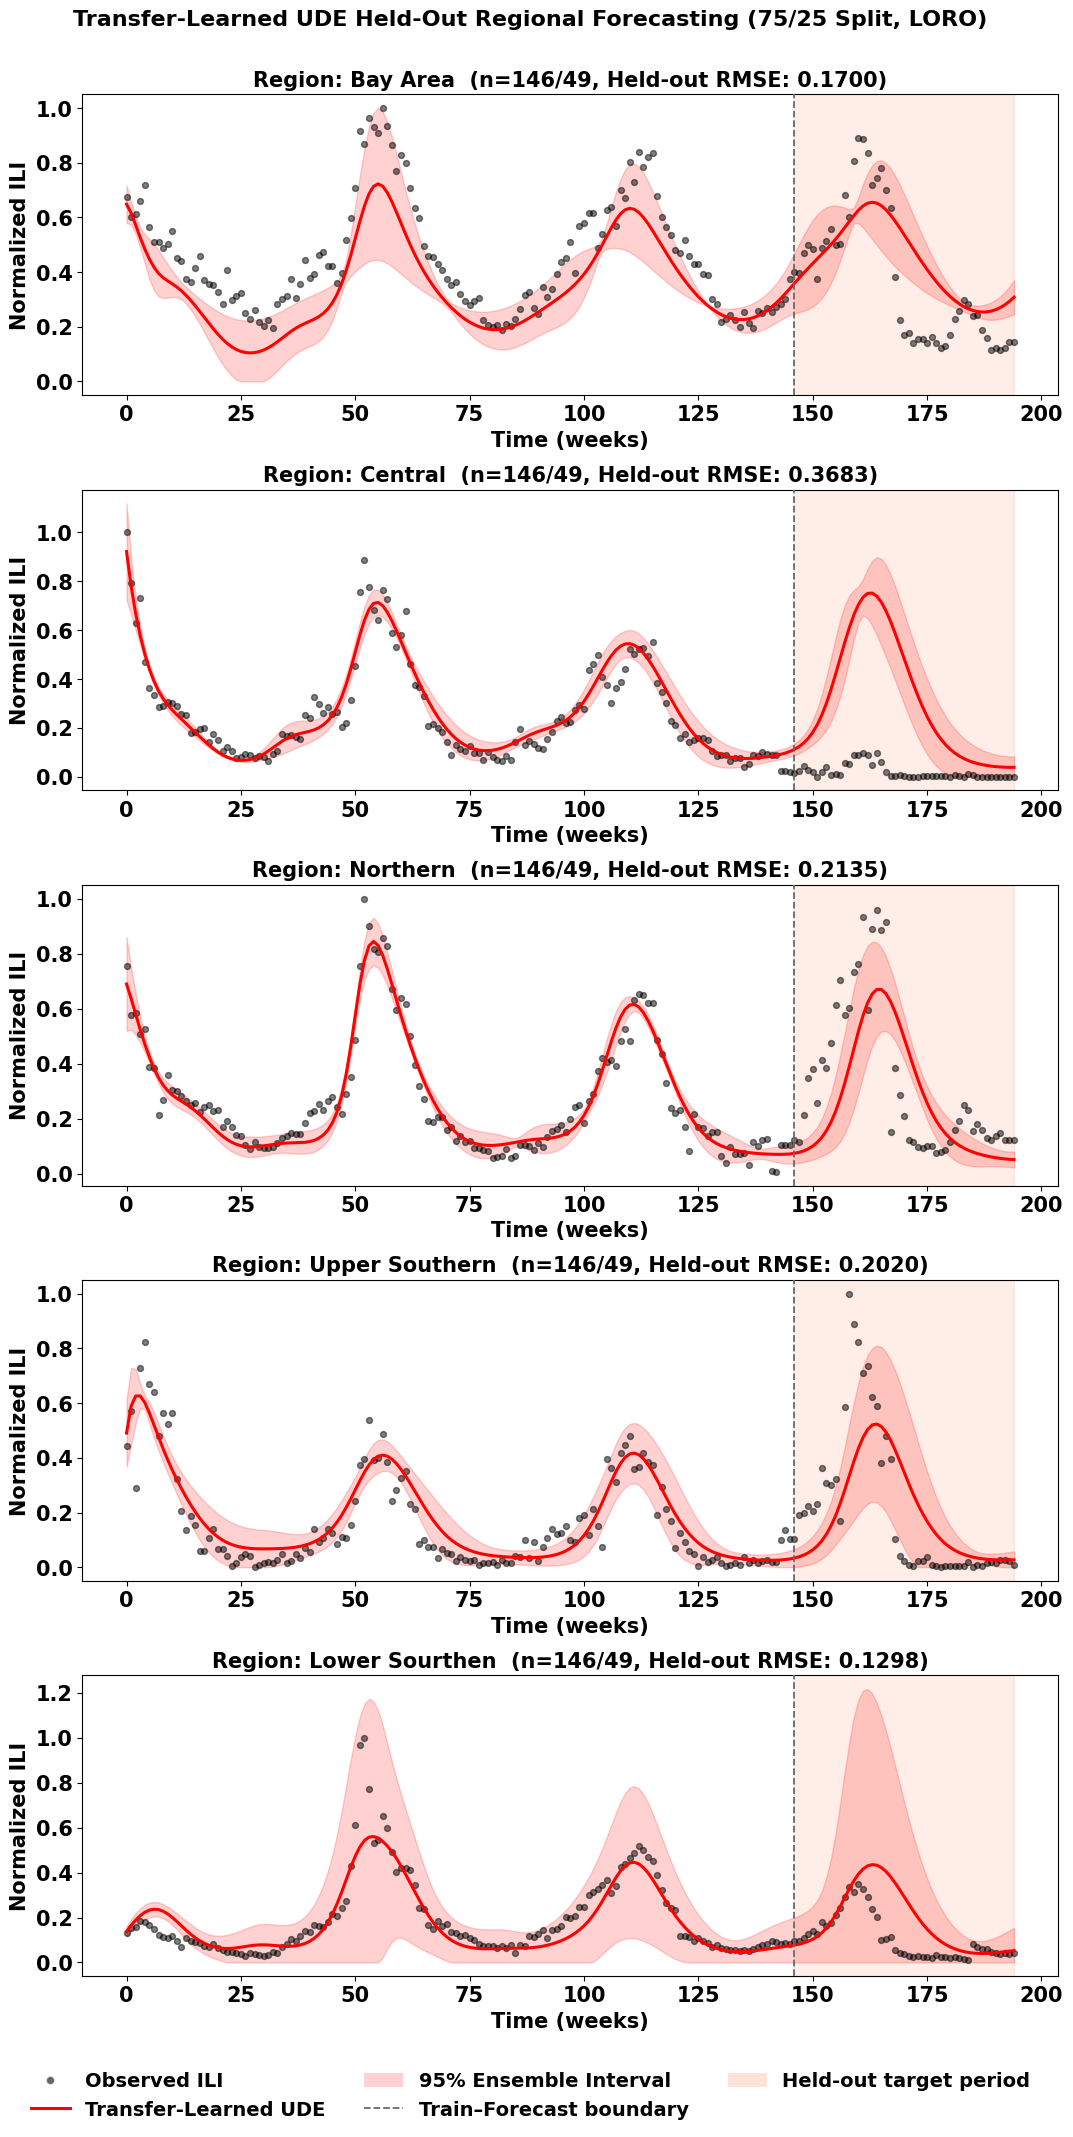


=== Table: Held-Out (75/25) Forecast Performance by Region ===


,Region,N_train,N_test,Split Week,RMSE,MAE,MAPE (%),sMAPE (%)
0,Bay Area,146.000000,49.000000,146,0.1700,0.1354,67.67%,41.79%
1,Central,146.000000,49.000000,146,0.3683,0.2886,392344384.00%,180.66%
2,Northern,146.000000,49.000000,146,0.2135,0.1819,79.09%,70.94%
3,Upper Southern,146.000000,49.000000,146,0.2020,0.1478,28154156.00%,103.06%
4,Lower Sourthen,146.000000,49.000000,146,0.1298,0.0859,184.40%,66.17%
5,Average,146.000000,49.000000,146,0.2167,0.1679,84099768.00%,92.53%


In [ ]:
# --------------------------------------------------
# BLOCK 21 : FIGURE 3 - LORO Held-Out Regional Forecasting (75/25 Split)
# Untruncated data only. Uses the shared plotter from Block 21/22, so
# layout (5 rows, 1 column) and legend wording match Figure 4 exactly.
# --------------------------------------------------

if ('region_names' not in globals() or 'main_predictions_untruncated' not in globals()
        or 'main_results_untruncated_df' not in globals()):
    print("ERROR: Required data for plotting (region_names, main_predictions_untruncated, "
          "main_results_untruncated_df) is not available.")
    print("Please ensure Block 20 (LORO) has been executed successfully before running this cell.")
else:
    fig3, axes3 = plot_regional_forecast_panels(
        region_order=region_names,
        predictions=main_predictions_untruncated,
        mode="loro",
        results_df=main_results_untruncated_df,
        region_key_name="Region",
        suptitle="Transfer-Learned UDE Held-Out Regional Forecasting (75/25 Split, LORO)",
        save_path="figure3_loro_forecast.png",
    )

    display_df = main_results_untruncated_df.copy()
    print("\n=== Table: Held-Out (75/25) Forecast Performance by Region ===")
    display(display_df.style.format({
        "Split Week": "{:.0f}", "RMSE": "{:.4f}", "MAE": "{:.4f}",
        "MAPE (%)": "{:.2f}%", "sMAPE (%)": "{:.2f}%"
    }).background_gradient(cmap="RdYlGn_r", subset=["RMSE", "MAE", "MAPE (%)", "sMAPE (%)"]))


Block 22: External Validation on Aggregate California (Fig. 14)

This reuses your existing single-region California fit (Blocks 8/10) — it's the natural "external validation" since California itself is the aggregate of the five regions.

Block 22: Figure 4 — Prospective Future Forecast per Region (+25 weeks, up to week 219)

=== Prospective Forecast (warm-start): Bay Area ===
  Forecast window: weeks 195 to 219
=== Prospective Forecast (warm-start): Central ===
  Forecast window: weeks 195 to 219
=== Prospective Forecast (warm-start): Northern ===
  Forecast window: weeks 195 to 219
=== Prospective Forecast (warm-start): Upper Southern ===
  Forecast window: weeks 195 to 219
=== Prospective Forecast (warm-start): Lower Sourthen ===
  Forecast window: weeks 195 to 219


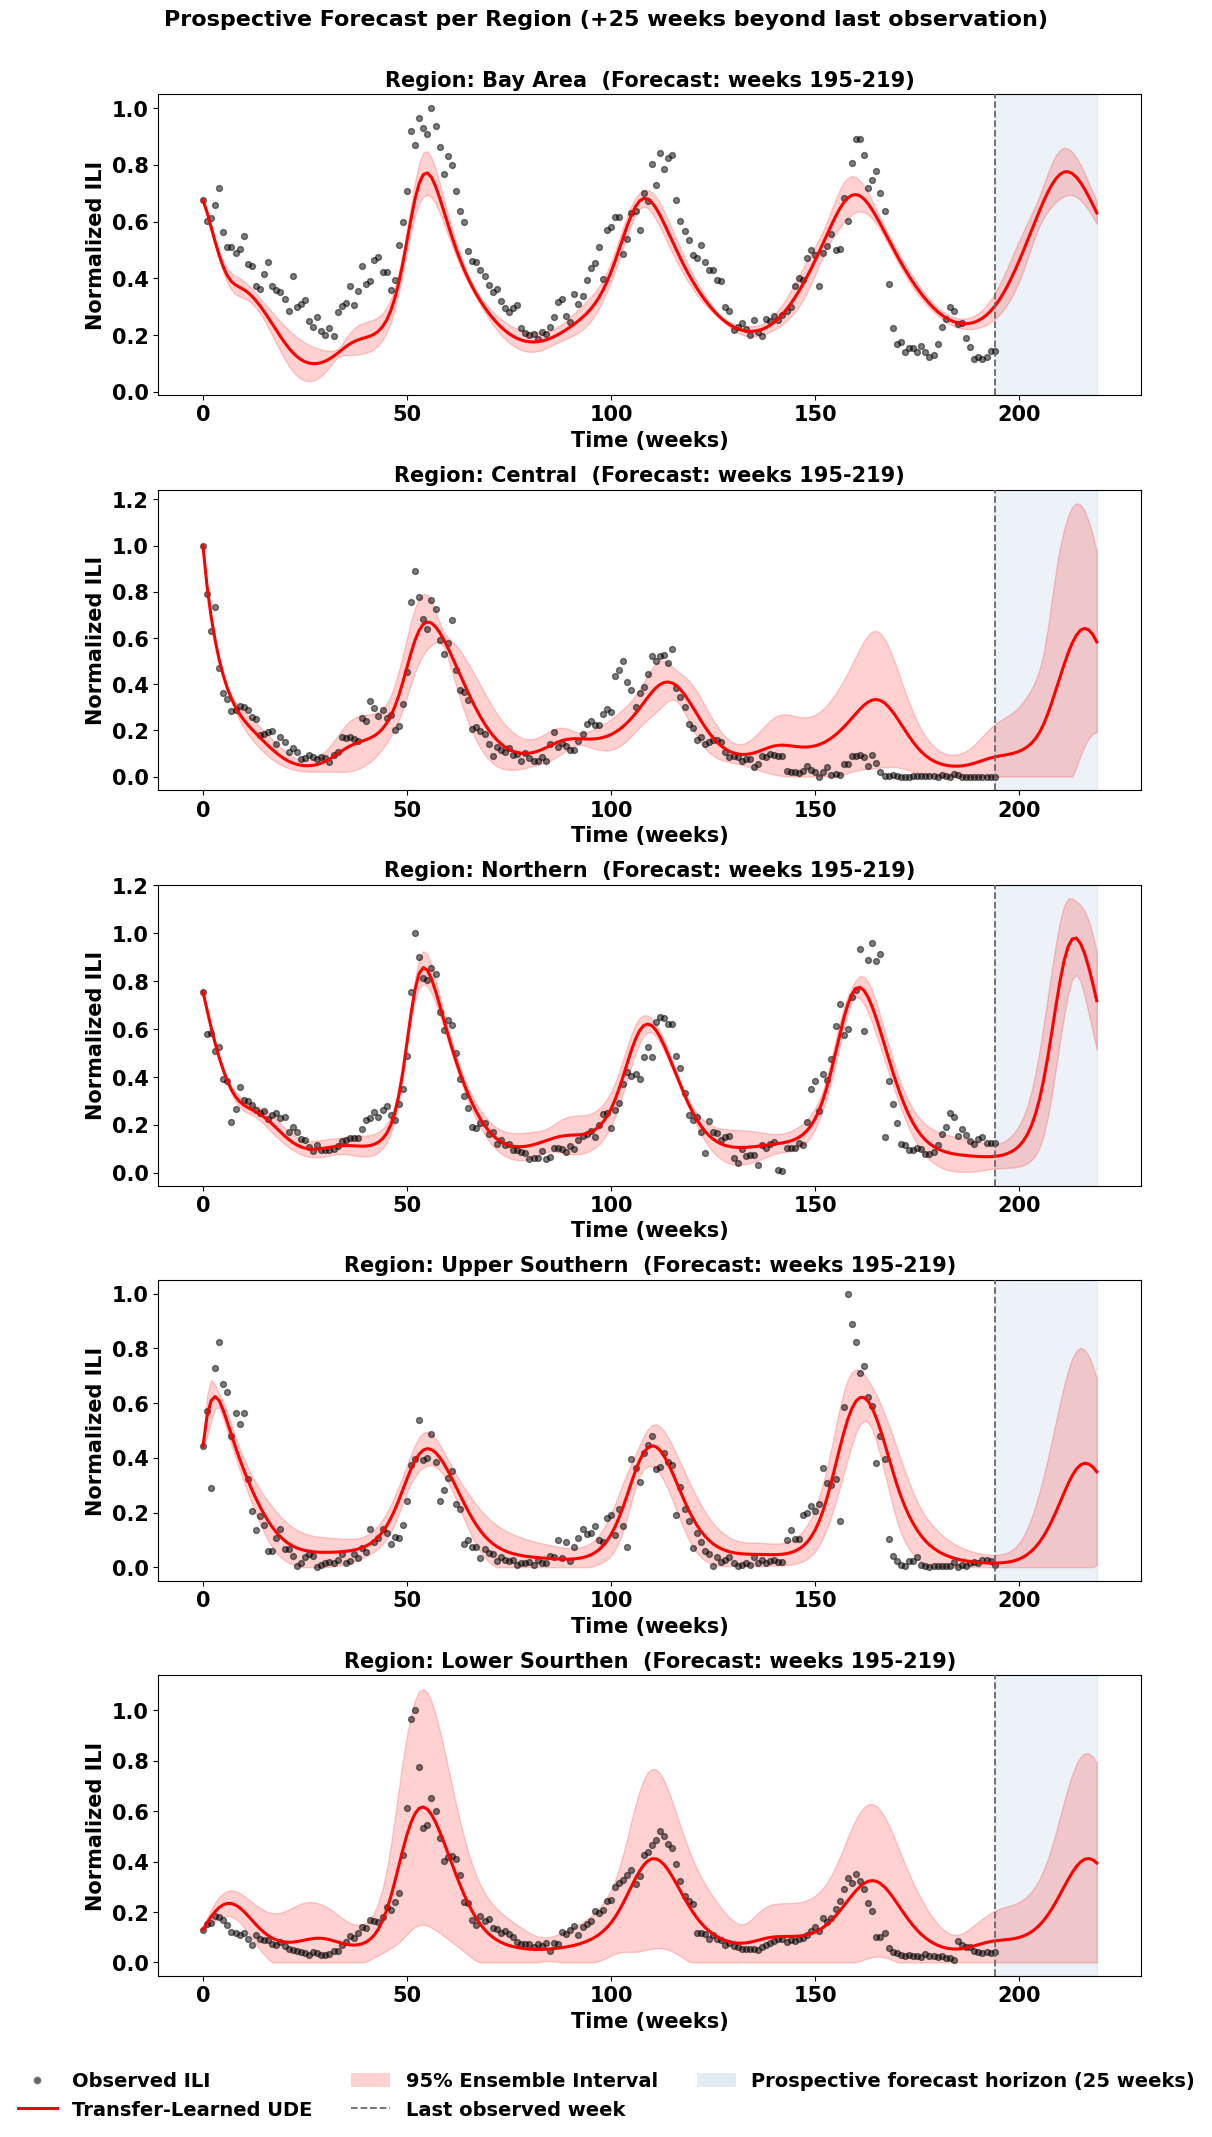


NOTE: No ground truth exists beyond each region's last observed week.
These are forward Forecast, not validated forecasts -- report them as such.


In [ ]:
# --------------------------------------------------
# BLOCK 22 : FIGURE 4 - Prospective Future Forecast per Region
# FIXED: now warm-starts from Block 20's trained, transfer-learned
# ensembles instead of retraining a separate, non-transferred ensemble
# from scratch. This makes the model shown here consistent with what
# the legend ("Transfer-Learned UDE") actually claims.
# --------------------------------------------------

FUTURE_HORIZON_WEEKS = 25
FINAL_FINETUNE_EPOCHS = 40   # short warm-start fine-tune, not 200 from scratch

def warm_start_prospective_forecast(t_full, I_full, params, horizon_weeks,
                                     ensemble_state_dicts, lam_r=1e-3,
                                     finetune_epochs=FINAL_FINETUNE_EPOCHS, lr=2e-4):
    """Takes the already-trained, transfer-learned ensemble from Block 20
    (trained on the 75% split), briefly fine-tunes each member on the
    FULL observed series (adding back the held-out 25%), then projects
    forward. Much cheaper than retraining from scratch, and consistent
    with the transfer-learning framework used throughout the paper."""
    last_week = t_full[-1]
    t_future_extra = np.arange(last_week + 1, last_week + horizon_weeks + 1, dtype=np.float32)
    t_plot = np.concatenate([t_full, t_future_extra])
    t_plot_tensor = torch.tensor(t_plot, dtype=torch.float32, device=device)

    ensemble_preds = []
    for state_dict in ensemble_state_dicts:
        model_f, ode_func_f, X0_f, _, _ = train_ude_regularized(
            t_full, I_full, params, lam_r=lam_r, epochs=finetune_epochs,
            lr=lr, seed=None, init_state_dict=state_dict
        )
        model_f.eval()
        with torch.no_grad():
            pred_X = odeint(ode_func_f, X0_f, t_plot_tensor, method="dopri5")
            if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)
            ensemble_preds.append(pred_X[:, 1].cpu().numpy())

    ensemble_preds = np.stack(ensemble_preds, axis=0)
    pred_mean = ensemble_preds.mean(axis=0)
    pred_std = ensemble_preds.std(axis=0)
    ci_lo = np.maximum(pred_mean - 1.96 * pred_std, 0.0)
    ci_hi = pred_mean + 1.96 * pred_std
    return t_plot, pred_mean, ci_lo, ci_hi

# --------------------------------------------------
# Run for each region, REUSING Block 20's transfer-learned ensembles
# --------------------------------------------------

prospective_results = {}
for name in region_names:
    print(f"=== Prospective Forecast (warm-start): {name} ===")
    d_region = region_data_untruncated[name]
    d_trained = main_predictions_untruncated[name]

    t_plot_r, pred_mean_r, ci_lo_r, ci_hi_r = warm_start_prospective_forecast(
        d_region["t"], d_region["I"], params, FUTURE_HORIZON_WEEKS,
        ensemble_state_dicts=d_trained["ensemble_state_dicts"]
    )
    prospective_results[name] = {
        "t_plot": t_plot_r, "pred_mean": pred_mean_r,
        "ci_lo": ci_lo_r, "ci_hi": ci_hi_r,
        "obs": d_region["I"], "t_obs": d_region["t"]
    }
    print(f"  Forecast window: weeks {int(d_region['t'][-1])+1} to {int(t_plot_r[-1])}")

# --------------------------------------------------
# Plot: 5 rows x 1 column
# --------------------------------------------------

fig4, axes4 = plot_regional_forecast_panels(
    region_order=list(prospective_results.keys()),
    predictions=prospective_results,
    mode="prospective",
    suptitle=f"Prospective Forecast per Region "
             f"(+{FUTURE_HORIZON_WEEKS} weeks beyond last observation)",
    save_path="figure4_prospective_forecast_per_region.png",
)

print("\nNOTE: No ground truth exists beyond each region's last observed week.")
print("These are forward Forecast, not validated forecasts -- report them as such.")